# Real-Time Customer Churn Prediction with Continual Learning and Explainability


**Checkpoint / freeze mechanism:** every expensive or critical step checks whether its output already exists in the `files/` folder on Drive. If it exists, it is *loaded*, not regenerated. This means that once a step has been run successfully, rerunning this notebook from scratch will not change any downstream results; it will simply reload the frozen artifacts.

In [ ]:
!pip install lightgbm river shap -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 26.8 MB/s eta 0:00:00


In [ ]:
!pip install numba==0.65.1 --quiet --force-reinstall
!pip install -q "numpy<2.1" river --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 37.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.9/18.9 MB 49.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 33.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tifffile 2026.8.23 requires numpy>=2.1, but you have numpy 2.0.2 which is incompatible.
dm-tree 0.1.10 requires numpy>=2.1.0; python_version >= "3.13", but you have numpy 2.0.2 which is incompatible.
jax 0.11.1 requires numpy>=2.1, but you have numpy 2.0.

In [ ]:
import os
import shutil
import pickle
from itertools import product
from functools import partial
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, f1_score, fbeta_score, precision_score,
    recall_score, balanced_accuracy_score, classification_report
)
import lightgbm as lgb
import river
from river import forest, drift
from scipy import stats#
import shap

from google.colab import drive
drive.mount('/content/drive')

save_path = '/content/drive/MyDrive/MSc Project/files/'
os.makedirs(save_path, exist_ok=True)

print(f"Save path: {save_path}")

Mounted at /content/drive
Save path: /content/drive/MyDrive/MSc Project/files/


## A - Exploratory Data Analysis

In [ ]:
df= pd.read_csv(save_path + 'WA_Fn-UseC_-Telco-Customer-Churn.csv')
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)

print(f"{df.shape}")
print(f"churn rate: {df['Churn'].mean():.2%}")

(7043, 21)
churn rate: 26.54%


In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [ ]:
churned_df = df[df['Churn'] == 1]

print("Percentage distribution for churned customers by categorical features\n")

cat_features = ['Contract', 'InternetService', 'PaymentMethod',
                'PaperlessBilling', 'SeniorCitizen', 'Partner', 'Dependents']

for feature in cat_features:
    percentage_distribution = churned_df[feature].value_counts(normalize=True) * 100
    print(percentage_distribution.map('{:.2f}%'.format))
    print("\n")

Percentage distribution for churned customers by categorical features

Contract
Month-to-month    88.55%
One year           8.88%
Two year           2.57%
Name: proportion, dtype: object


InternetService
Fiber optic    69.40%
DSL            24.56%
No              6.05%
Name: proportion, dtype: object


PaymentMethod
Electronic check             57.30%
Mailed check                 16.48%
Bank transfer (automatic)    13.80%
Credit card (automatic)      12.41%
Name: proportion, dtype: object


PaperlessBilling
Yes    74.91%
No     25.09%
Name: proportion, dtype: object


SeniorCitizen
0    74.53%
1    25.47%
Name: proportion, dtype: object


Partner
No     64.21%
Yes    35.79%
Name: proportion, dtype: object


Dependents
No     82.56%
Yes    17.44%
Name: proportion, dtype: object




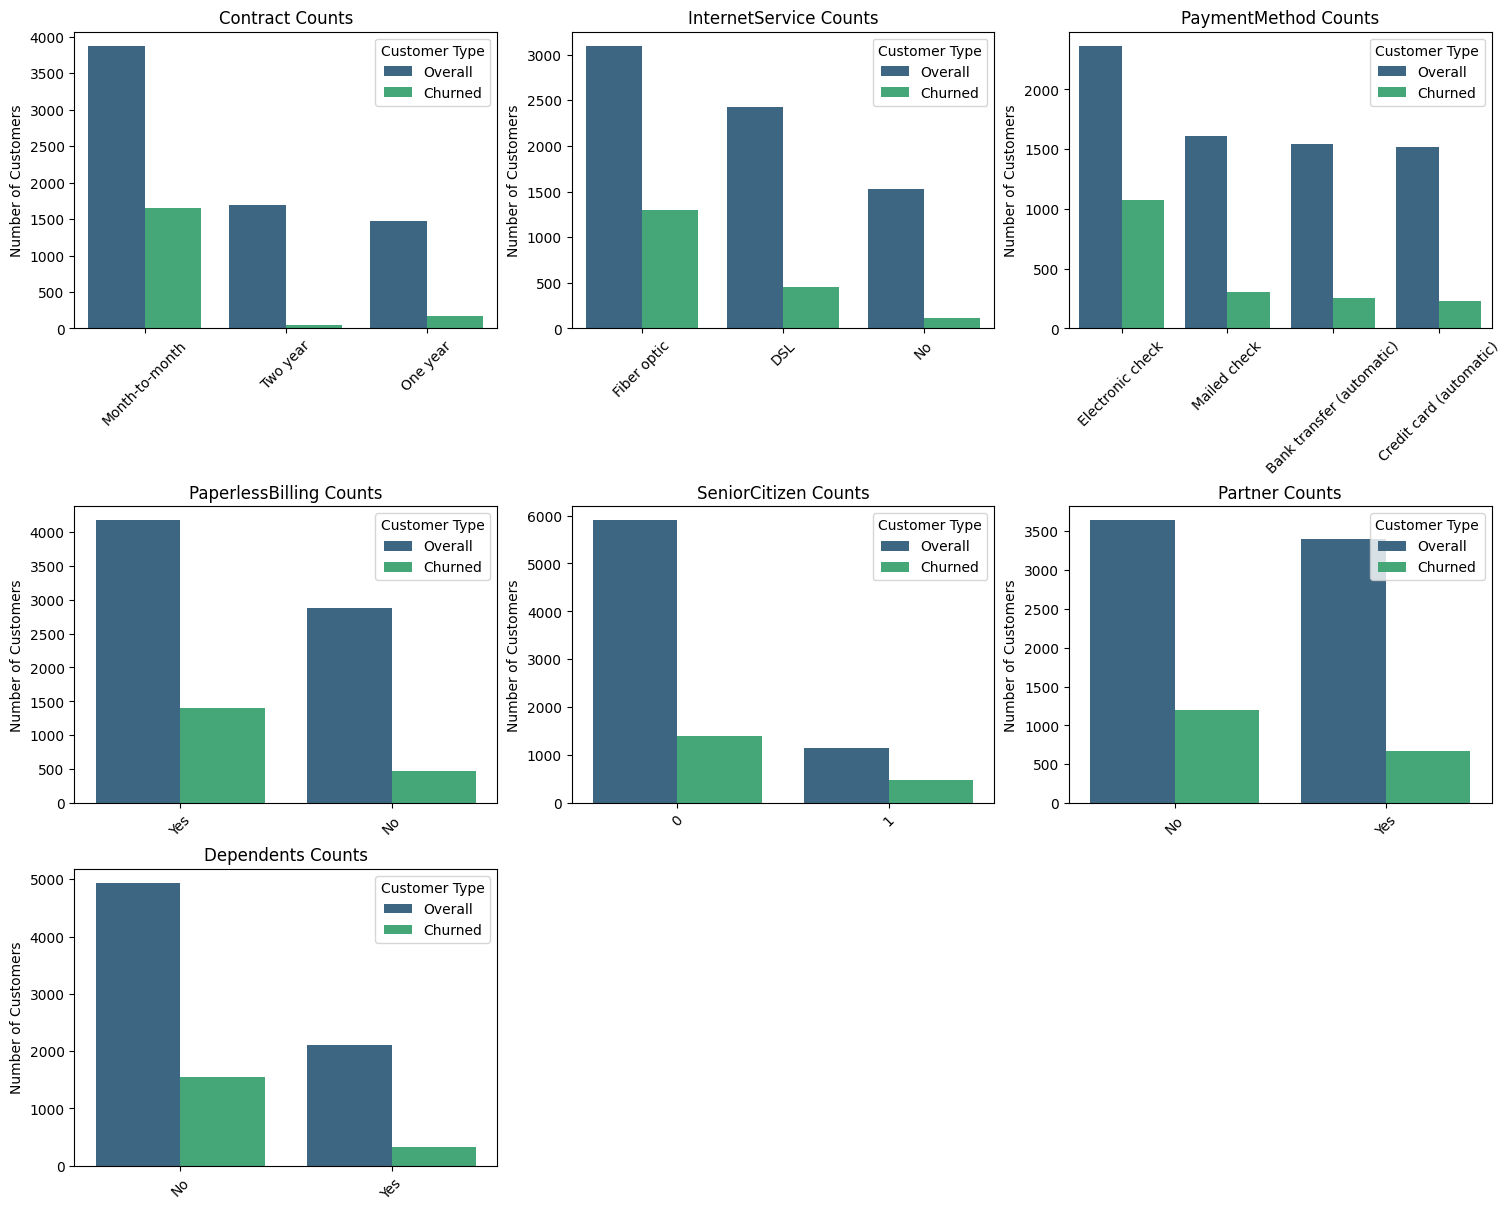

In [ ]:
num_features = len(cat_features)
num_cols = 3
num_rows = (num_features + num_cols - 1) // num_cols

fig_counts, axes_counts = plt.subplots(num_rows, num_cols, figsize=(num_cols * 5, num_rows * 4), constrained_layout=True)
axes_counts = axes_counts.flatten() if num_rows > 1 else [axes_counts]

for i, feature in enumerate(cat_features):
    ax = axes_counts[i]

    overall_counts = df[feature].value_counts().reset_index()
    overall_counts.columns = [feature, 'Count']
    overall_counts['Type'] = 'Overall'

    churned_counts = churned_df[feature].value_counts().reset_index()
    churned_counts.columns = [feature, 'Count']
    churned_counts['Type'] = 'Churned'

    combined_counts_df = pd.concat([overall_counts, churned_counts])

    sns.barplot(x=feature, y='Count', hue='Type', data=combined_counts_df, ax=ax, palette='viridis')
    ax.set_title(f'{feature} Counts')
    ax.set_ylabel('Number of Customers')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(title='Customer Type')

for j in range(i + 1, len(axes_counts)):
    fig_counts.delaxes(axes_counts[j])

plt.show()

In [ ]:
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

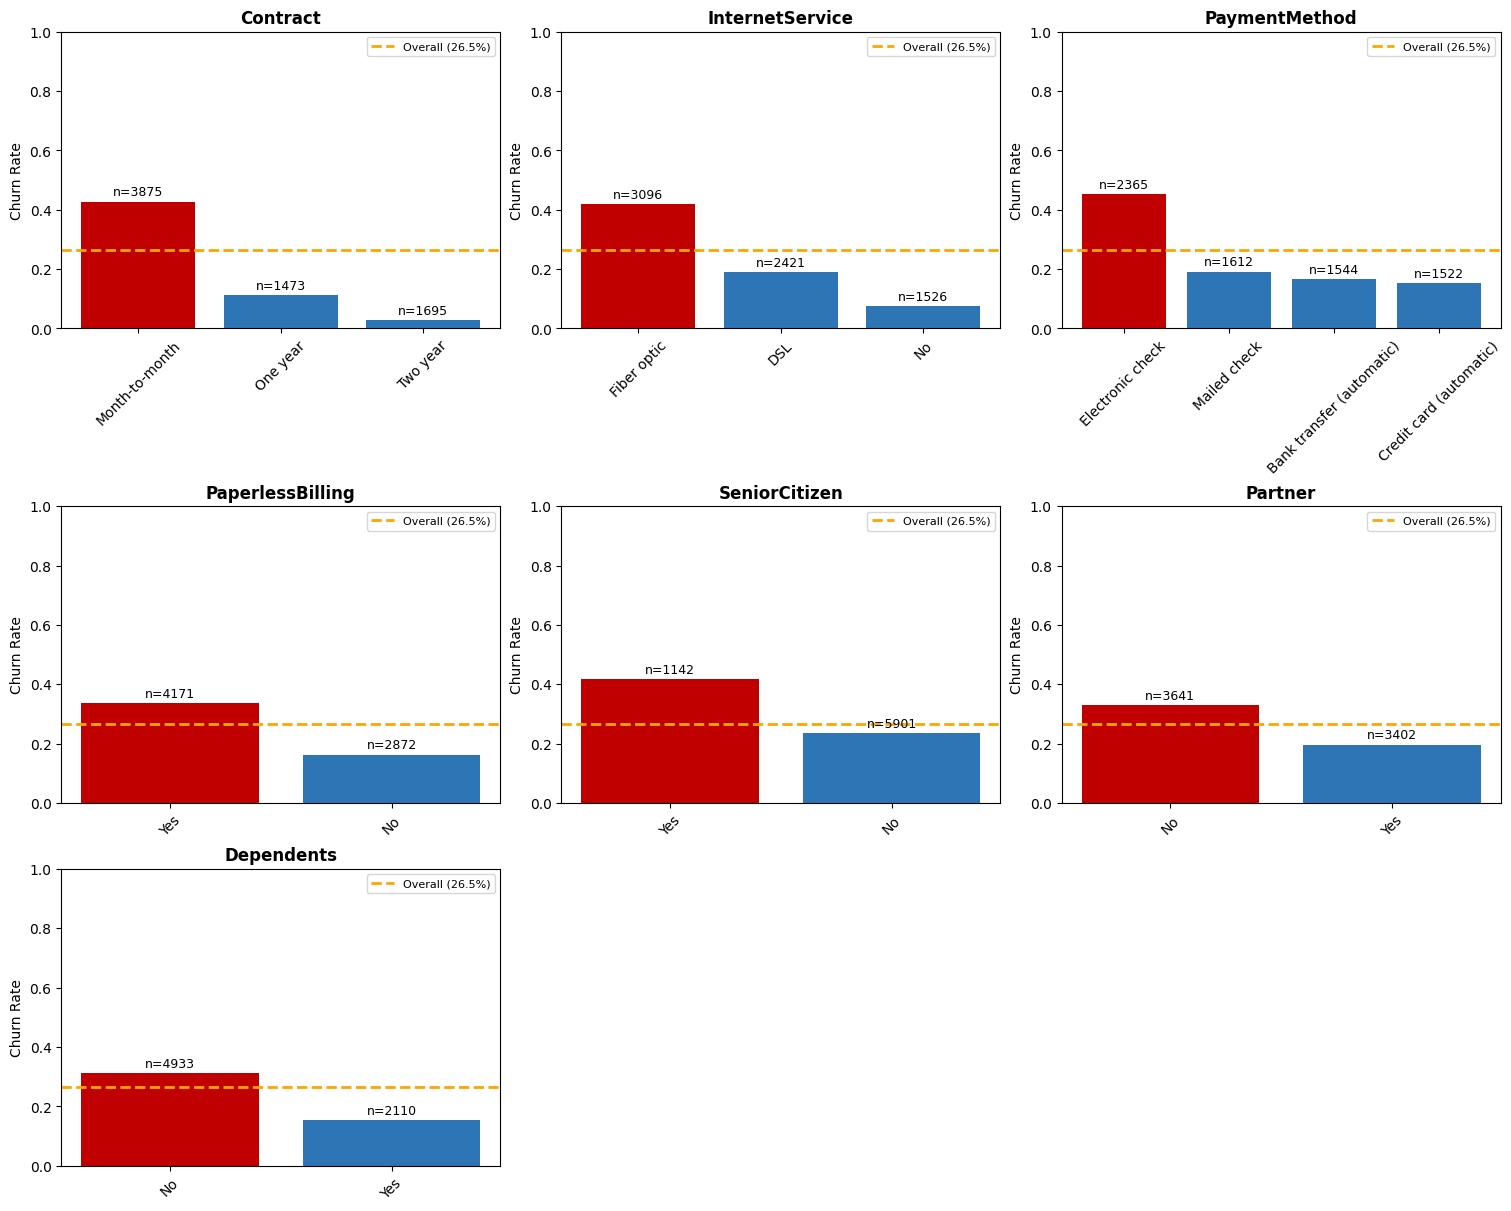

In [ ]:
num_features_to_plot = len(cat_features)
num_cols = 3
num_rows = (num_features_to_plot + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 5, num_rows * 4), constrained_layout=True)
axes = axes.flatten() if num_rows > 1 else [axes]

for i, feat in enumerate(cat_features):
    ax = axes[i]
    churn_rate = df.groupby(feat)['Churn'].mean().sort_values(ascending=False)
    count      = df.groupby(feat)['Churn'].count().reindex(churn_rate.index)

    bars = ax.bar(churn_rate.index, churn_rate.values,
                  color=['#C00000' if v > 0.3 else '#2E75B6' for v in churn_rate.values])
    ax.axhline(y=df['Churn'].mean(), color='orange',
               linestyle='--', linewidth=2, label=f'Overall ({df["Churn"].mean():.1%})')
    ax.set_title(feat, fontweight='bold')
    ax.set_ylabel('Churn Rate')
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)

    for bar, (idx, cnt) in zip(bars, count.items()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'n={cnt}', ha='center', fontsize=9)

    ax.tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.show()

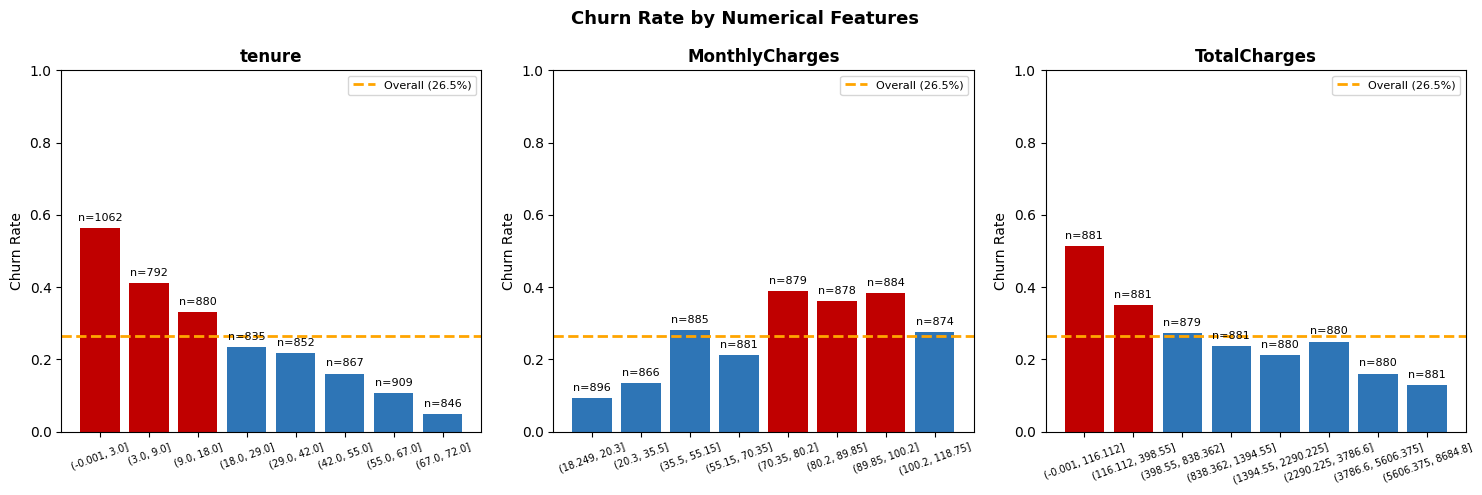

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Churn Rate by Numerical Features', fontsize=13, fontweight='bold')

num_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

for ax, feat in zip(axes, num_features):
    df[f'{feat}_bin'] = pd.qcut(df[feat], q=8, duplicates='drop')
    churn_by_bin = df.groupby(f'{feat}_bin',observed=False)['Churn'].mean()
    count_by_bin = df.groupby(f'{feat}_bin',observed=False)['Churn'].count()

    bars = ax.bar(range(len(churn_by_bin)), churn_by_bin.values,
                  color=['#C00000' if v > 0.3 else '#2E75B6' for v in churn_by_bin.values])
    ax.axhline(y=df['Churn'].mean(), color='orange',
               linestyle='--', linewidth=2, label=f'Overall ({df["Churn"].mean():.1%})')
    ax.set_xticks(range(len(churn_by_bin)))
    ax.set_xticklabels([str(x) for x in churn_by_bin.index], rotation=20, fontsize=7)
    ax.set_title(feat, fontweight='bold')
    ax.set_ylabel('Churn Rate')
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)

    for bar, cnt in zip(bars, count_by_bin.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'n={cnt}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

df.drop(columns=[f'{feat}_bin' for feat in num_features], inplace=True)

In [ ]:
# n is around 1400 for each group.
# Old customers are more loyal.
# high monthly charges have more churn rate.
# So ones that are new customers and pay more, have more churn chance.

In [ ]:
cross_tab = df.groupby(['Contract', 'InternetService'])['Churn'].agg(['mean', 'count'])
cross_tab.columns = ['Churn Rate', 'Count']
cross_tab['Churn Rate'] = cross_tab['Churn Rate'].map('{:.1%}'.format)
print("Churn Rate by Contract and Internet Service:")
print(cross_tab.to_string())

Churn Rate by Contract and Internet Service:
                               Churn Rate  Count
Contract       InternetService                  
Month-to-month DSL                  32.2%   1223
               Fiber optic          54.6%   2128
               No                   18.9%    524
One year       DSL                   9.3%    570
               Fiber optic          19.3%    539
               No                    2.5%    364
Two year       DSL                   1.9%    628
               Fiber optic           7.2%    429
               No                    0.8%    638


In [ ]:
cat_features = ['Contract', 'InternetService', 'PaymentMethod',
                'PaperlessBilling', 'SeniorCitizen', 'Partner', 'Dependents']

result = df.groupby(cat_features)['Churn'].agg(['mean', 'count'])
result.columns = ['Churn Rate', 'Count']
result = result[result['Count'] >= 30].sort_values('Churn Rate', ascending=False)

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

display(result)

pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')

Churn Rate  \
Contract       InternetService PaymentMethod             PaperlessBilling SeniorCitizen Partner Dependents               
Month-to-month Fiber optic     Electronic check          Yes              Yes           No      No            0.708134   
                                                                          No            No      No            0.657767   
                               Bank transfer (automatic) Yes              Yes           Yes     No            0.593750   
                               Electronic check          Yes              No            Yes     No            0.585526   
                               Credit card (automatic)   Yes              Yes           No      No            0.583333   
                               Electronic check          Yes              Yes           Yes     No            0.572414   
                                                                          No            Yes     Yes           0.560000   
                                                         No               No            No      No            0.525862   
               DSL             Electronic check          Yes              Yes           No      No            0.512195   
               Fiber optic     Bank transfer (automatic) Yes              No            No      No            0.500000   
                               Electronic check          No               No            Yes     Yes           0.486486   
               DSL             Electronic check          Yes              No            Yes     No            0.485714   
               Fiber optic     Mailed check              Yes              No            No      No            0.475000   
                                                         No               No            No      No            0.472222   
                               Bank transfer (automatic) No               No            No      No            0.472222   
                                                         Yes              No            Yes     No            0.461538   
               DSL             Electronic check          Yes              No            No      No            0.458599   
               Fiber optic     Electronic check          No               No            Yes     No            0.454545   
                               Credit card (automatic)   Yes              No            No      No            0.417582   
                               Bank transfer (automatic) Yes              No            Yes     Yes           0.416667   
               DSL             Mailed check              Yes              No            No      No            0.396396   
               Fiber optic     Credit card (automatic)   Yes              No            Yes     No            0.386364   
                               Bank transfer (automatic) Yes              Yes           No      No            0.382353   
               DSL             Credit card (automatic)   Yes              No            No      No            0.360656   
                               Electronic check          No               No            No      No            0.333333   
               No              Mailed check              Yes              No            No      No            0.301587   
               DSL             Mailed check              No               No            Yes     Yes           0.300000   
                               Electronic check          Yes              No            Yes     Yes           0.281250   
                               Mailed check              No               No            No      No            0.277228   
                               Electronic check          No               No            Yes     Yes           0.272727   
One year       Fiber optic     Electronic check          Yes              No            Yes     No            0.261905   
Month-to-month DSL             Bank transfer (automatic) Yes              No      

In [ ]:
cat_features = ['Contract', 'InternetService', 'PaymentMethod',
                'PaperlessBilling', 'SeniorCitizen', 'Partner', 'Dependents']

result = df.groupby(cat_features)['Churn'].agg(['mean', 'count'])
result.columns = ['Churn Rate', 'Count']
result = result[result['Count'] >= 30].sort_values('Churn Rate', ascending=False)

print(f"Segments with at least 30 customers: {len(result)}")
print(f"Segments with zero churn: {(result['Churn Rate'] == 0).sum()}")

print("\nFive highest-churn segments:")
print(result.head(5).to_string())

print("\nFive lowest-churn segments:")
print(result.tail(5).to_string())

Segments with at least 30 customers: 59
Segments with zero churn: 9

Five highest-churn segments:
                                                                                                            Churn Rate  Count
Contract       InternetService PaymentMethod             PaperlessBilling SeniorCitizen Partner Dependents                   
Month-to-month Fiber optic     Electronic check          Yes              Yes           No      No            0.708134    209
                                                                          No            No      No            0.657767    412
                               Bank transfer (automatic) Yes              Yes           Yes     No            0.593750     32
                               Electronic check          Yes              No            Yes     No            0.585526    152
                               Credit card (automatic)   Yes              Yes           No      No            0.583333     36

Five lowest-churn s

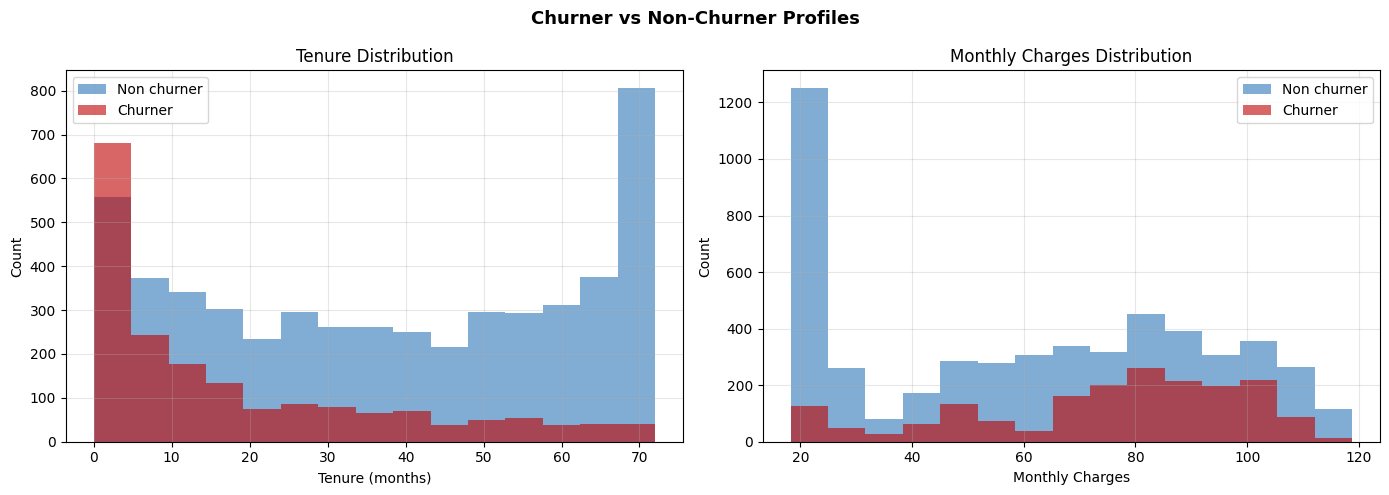

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Churner vs Non-Churner Profiles', fontsize=13, fontweight='bold')

num_features = [('tenure', 'Tenure Distribution', 'Tenure (months)'),
                ('MonthlyCharges', 'Monthly Charges Distribution', 'Monthly Charges')]

for ax, (feat, title, xlabel) in zip(axes, num_features):
    bins = np.linspace(df[feat].min(), df[feat].max(), 16)

    ax.hist(df[df['Churn'] == 0][feat], bins=bins, alpha=0.6,
            color='#2E75B6', label='Non churner')
    ax.hist(df[df['Churn'] == 1][feat], bins=bins, alpha=0.6,
            color='#C00000', label='Churner')

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Count')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

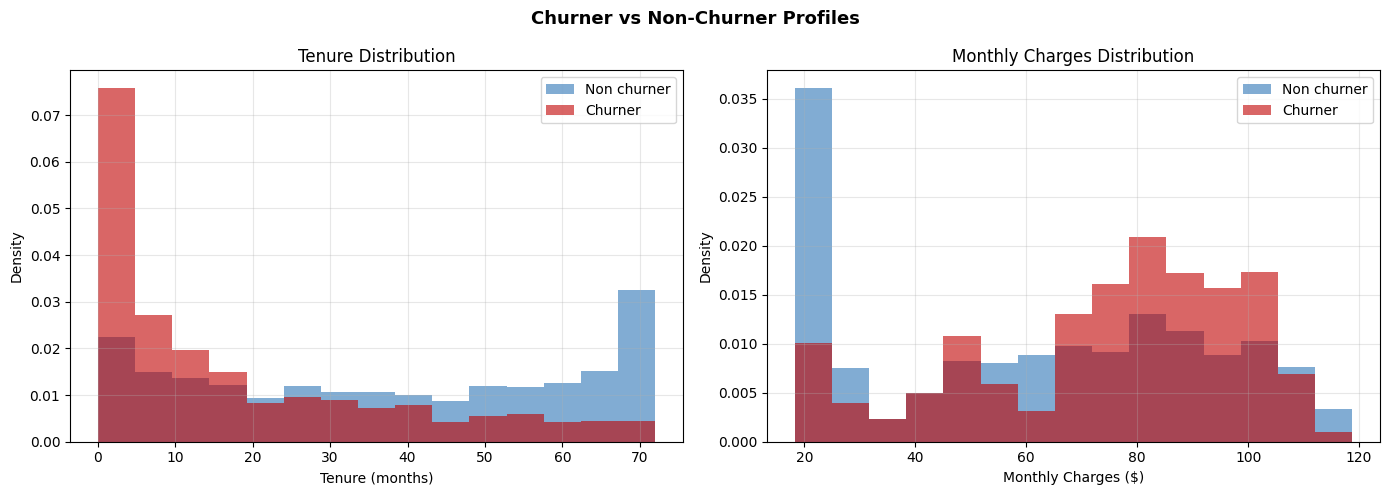

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Churner vs Non-Churner Profiles', fontsize=13, fontweight='bold')

num_features = [('tenure', 'Tenure Distribution', 'Tenure (months)'),
                ('MonthlyCharges', 'Monthly Charges Distribution', 'Monthly Charges ($)')]

for ax, (feat, title, xlabel) in zip(axes, num_features):
    bins = np.linspace(df[feat].min(), df[feat].max(), 16)

    ax.hist(df[df['Churn'] == 0][feat], bins=bins, alpha=0.6,
            color='#2E75B6', label='Non churner', density=True)
    ax.hist(df[df['Churn'] == 1][feat], bins=bins, alpha=0.6,
            color='#C00000', label='Churner', density=True)

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Correlation matrix of numerical attributes:

print(df[['tenure', 'MonthlyCharges', 'TotalCharges']].corr().round(4).to_string())

                tenure  MonthlyCharges  TotalCharges
tenure          1.0000          0.2479        0.8262
MonthlyCharges  0.2479          1.0000        0.6512
TotalCharges    0.8262          0.6512        1.0000


---
## B - Preprocessing

If `X_train.csv`, `y_train.csv`, `scaler.pkl` and `simulation_batches.pkl` already exist in `files/`, they are loaded directly and the main CSV file wont be reprocessed.

In [ ]:
# This function checks if the cell is running for the first time or not. If the files exist in the files, it wont run so the consistancy of generated data will be kept.
def checkpoint_exists(*filenames):
    return all(os.path.exists(save_path + fname) for fname in filenames)

In [ ]:
_PREPROC_FILES = ['X_train.csv', 'y_train.csv', 'scaler.pkl', 'simulation_batches.pkl']
_NEED_PREPROCESSING = not checkpoint_exists(*_PREPROC_FILES)

if not _NEED_PREPROCESSING:
    print("Working on existing data")

    X_train = pd.read_csv(save_path + 'X_train.csv')
    y_train = pd.read_csv(save_path + 'y_train.csv').squeeze()

    with open(save_path + 'scaler.pkl', 'rb') as f:
        scaler = pickle.load(f)

    with open(save_path + 'simulation_batches.pkl', 'rb') as f:
        _sim_batches = pickle.load(f)
    batches_X = _sim_batches['X']
    batches_y = _sim_batches['y']

    print(f"Loaded X_train: {X_train.shape}")
    print(f"Loaded {len(batches_X)} simulation batches")
else:
    print("No preprocessed data found; running full preprocessing pipeline")

No preprocessed data found; running full preprocessing pipeline


In [ ]:
# Kaggle: IBM Telco Customer Churn

if _NEED_PREPROCESSING:
    df = pd.read_csv(save_path + 'WA_Fn-UseC_-Telco-Customer-Churn.csv')
    print(df.shape)

(7043, 21)


In [ ]:
if _NEED_PREPROCESSING:
    print(df.dtypes)
    print(df.isnull().sum())
    print(df['Churn'].value_counts())
    print(f"Churn rate: {df['Churn'].value_counts(normalize=True)['Yes']:.2%}")

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
Mo

In [ ]:
# TotalCharges is stored as object, so it must convert to numeric.

if _NEED_PREPROCESSING:
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    print(df['TotalCharges'].isna().sum())

11


In [ ]:
# the TotalCharges column had some null values like '', which showed up when converting to numeric.

if _NEED_PREPROCESSING:
    print(df[df['TotalCharges'].isnull()][['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']])

      tenure  MonthlyCharges  TotalCharges Churn
488        0           52.55           NaN    No
753        0           20.25           NaN    No
936        0           80.85           NaN    No
1082       0           25.75           NaN    No
1340       0           56.05           NaN    No
3331       0           19.85           NaN    No
3826       0           25.35           NaN    No
4380       0           20.00           NaN    No
5218       0           19.70           NaN    No
6670       0           73.35           NaN    No
6754       0           61.90           NaN    No


In [ ]:
# These are new customers that haven't been charged yet. So filling them with zero because they haven't been charged yet.

if _NEED_PREPROCESSING:
    df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [ ]:
# CustomerID is not needed for modeling so it will be dropped.

if _NEED_PREPROCESSING:
    df = df.drop(columns=['customerID'])

In [ ]:
# PhoneService and MultipleLines must be merged to avoid redundancy.
# Same thing applies to InternetService column and other related features to it.
# Performing feature engineering on PhoneService and MultipleLines and merging them to be able to do encoding on it in a better way.
# Currently:
# PhoneService: Yes / No
# MultipleLines: Yes / No / No phone service

if _NEED_PREPROCESSING:
    def encode_phone(row):
        if row['PhoneService'] == 'No':
            return 0  # No phone service
        elif row['MultipleLines'] == 'No':
            return 1  # Phone service only
        else:
            return 2  # Phone service + multiple lines

    df['PhoneCategory'] = df.apply(encode_phone, axis=1)
    df = df.drop(columns=['PhoneService', 'MultipleLines'])

In [ ]:
# Performing feature engineering on Internet services. If a customer doesn't have internet service at all, relevant internet
# features will be 'No internet Service', which is redundant and increases dimension after encoding, so those values would be
# replaced with 'No' instead.

if _NEED_PREPROCESSING:
    internet_dependents = [
        'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
        'TechSupport', 'StreamingTV', 'StreamingMovies']

    for col in internet_dependents:
        df[col] = df[col].replace('No internet service', 'No')

In [ ]:
# Calculating information gain on each feature.
# Using Sturges' formula, number of categories for 7043 observations would be 14.
# So, numeric features will be factorised into 14 categories.

if _NEED_PREPROCESSING:
    df_fs = df.copy()
    numeric = ['tenure', 'MonthlyCharges', 'TotalCharges']

    for c in numeric:
        df_fs[c] = pd.qcut(df_fs[c], q=14, labels=False, duplicates='drop')

    df_enc = df_fs.copy()
    for c in df_enc.columns:
        if df_enc[c].dtype == 'object':
            df_enc[c] = pd.factorize(df_enc[c])[0]

    print(df_enc.dtypes.value_counts())
    print(df_enc.shape)

int64    19
Name: count, dtype: int64
(7043, 19)


In [ ]:
if _NEED_PREPROCESSING:
    def entropy(series):
        p = series.value_counts(normalize=True)
        return -(p * np.log2(p)).sum()

    def information_gain(feature, y):
        H_y = entropy(y)
        H_y_given_x = 0.0
        for value, group in y.groupby(feature):
            H_y_given_x += (len(group) / len(y)) * entropy(group)
        return H_y - H_y_given_x

    def split_info(feature):
        p = feature.value_counts(normalize=True)
        return -(p * np.log2(p)).sum()

In [ ]:
# Calculated both IG and IG_ratio to bypass the bias towards ones that have more categories and gain more value.

if _NEED_PREPROCESSING:
    target = 'Churn'
    y_all = df_enc[target]
    X_all = df_enc.drop(columns=[target])

    X_fs, _, y_fs, _ = train_test_split(
        X_all, y_all, test_size=0.30, stratify=y_all, random_state=2026)

    rows = []
    for c in X_fs.columns:
        ig = information_gain(X_fs[c], y_fs)
        si = split_info(X_fs[c])
        rows.append({
            'feature': c,
            'info_gain': ig,
            'gain_ratio': ig / si if si > 0 else 0.0,
            'n_values': X_fs[c].nunique()
        })

    ranking = (pd.DataFrame(rows)
                 .sort_values('gain_ratio', ascending=False)
                 .reset_index(drop=True))

    print(f"Baseline entropy H(Churn) = {entropy(y_fs):.4f} bits\n")
    print(ranking.round(4).to_string(index=False))

Baseline entropy H(Churn) = 0.8347 bits

         feature  info_gain  gain_ratio  n_values
        Contract     0.1432      0.0994         3
 InternetService     0.0744      0.0487         3
   PaymentMethod     0.0658      0.0334         4
          tenure     0.1140      0.0300        14
  OnlineSecurity     0.0238      0.0274         2
PaperlessBilling     0.0257      0.0265         2
     TechSupport     0.0221      0.0255         2
   SeniorCitizen     0.0150      0.0236         2
      Dependents     0.0199      0.0226         2
         Partner     0.0203      0.0203         2
    TotalCharges     0.0535      0.0140        14
  MonthlyCharges     0.0482      0.0127        14
    OnlineBackup     0.0078      0.0085         2
DeviceProtection     0.0041      0.0044         2
     StreamingTV     0.0015      0.0016         2
 StreamingMovies     0.0014      0.0015         2
   PhoneCategory     0.0006      0.0004         3
          gender     0.0001      0.0001         2


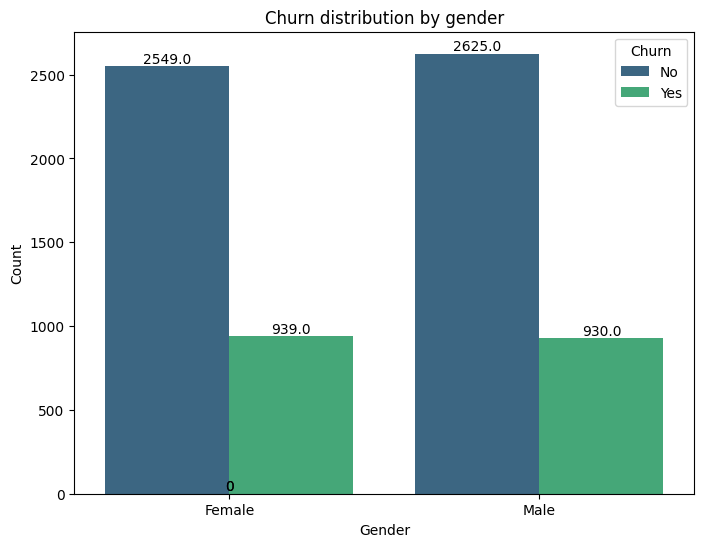

In [ ]:
# As predicted, the tenure has that bias; by calculating the ratio, real value of this feature is revealed.
# It seems like gender doesn't tell much.

if _NEED_PREPROCESSING:
    plt.figure(figsize=(8, 6))
    ax = sns.countplot(data=df_fs, x='gender', hue='Churn', palette='viridis')
    plt.title('Churn distribution by gender')
    plt.xlabel('Gender')
    plt.ylabel('Count')
    plt.legend(title='Churn')

    for p in ax.patches:
        ax.annotate(f'{p.get_height()}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 5),
                    textcoords='offset points')

    plt.show()

In [ ]:
# So gender feature will be dropped from dataset as it doesn't help with the prediction.

if _NEED_PREPROCESSING:
    print(df[['tenure', 'MonthlyCharges', 'TotalCharges']].corr().round(4))

                tenure  MonthlyCharges  TotalCharges
tenure          1.0000          0.2479        0.8262
MonthlyCharges  0.2479          1.0000        0.6512
TotalCharges    0.8262          0.6512        1.0000


In [ ]:
# Because there is high correlation between TotalCharges and tenure, this means that one of them is almost redundant and can be dropped.

if _NEED_PREPROCESSING:
    df.drop(columns=['gender', 'TotalCharges'], inplace=True)

In [ ]:
df.head(2)

,SeniorCitizen,Partner,Dependents,tenure,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn,PhoneCategory
0,0,Yes,No,1,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,No,0
1,0,No,No,34,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,No,1


In [ ]:
# Encoding
# The parameter of drop_first=False to keep them all for explainability.

if _NEED_PREPROCESSING:
    binary_cols = {
        'Partner': {'Yes': 1, 'No': 0},
        'Dependents': {'Yes': 1, 'No': 0},
        'PaperlessBilling': {'Yes': 1, 'No': 0},
    }
    for col, mapping in binary_cols.items():
        df[col] = df[col].map(mapping)

    for col in internet_dependents:
        df[col] = df[col].map({'Yes': 1, 'No': 0})

    multi_cat_cols = ['InternetService', 'Contract', 'PaymentMethod']
    df = pd.get_dummies(df, columns=multi_cat_cols, drop_first=False)

    print(df.shape)
    print(f"Columns: {list(df.columns)}")

(7043, 24)
Columns: ['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'Churn', 'PhoneCategory', 'InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [ ]:
if _NEED_PREPROCESSING:
    print(df.select_dtypes(include='object').columns.tolist())
    print(df.dtypes)

['Churn']
SeniorCitizen                                int64
Partner                                      int64
Dependents                                   int64
tenure                                       int64
OnlineSecurity                               int64
OnlineBackup                                 int64
DeviceProtection                             int64
TechSupport                                  int64
StreamingTV                                  int64
StreamingMovies                              int64
PaperlessBilling                             int64
MonthlyCharges                             float64
Churn                                       object
PhoneCategory                                int64
InternetService_DSL                           bool
InternetService_Fiber optic                   bool
InternetService_No                            bool
Contract_Month-to-month                       bool
Contract_One year                             bool
Contract_Two year    

In [ ]:
if _NEED_PREPROCESSING:
    df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
    bool_cols = df.select_dtypes(include='bool').columns.tolist()
    df[bool_cols] = df[bool_cols].astype(int)

    print(df['Churn'].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


In [ ]:
# Splitting

if _NEED_PREPROCESSING:

    X = df.drop(columns=['Churn'])
    y = df['Churn']

    X_train, X_sim, y_train, y_sim = train_test_split(
        X, y,
        test_size=0.30,
        random_state=2026,
        stratify=y
    )

In [ ]:
# Scaling: fit-transform on train and only transform on sim

if _NEED_PREPROCESSING:

    numerical_cols = ['tenure', 'MonthlyCharges']

    scaler = StandardScaler()
    X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
    X_sim[numerical_cols] = scaler.transform(X_sim[numerical_cols])

    print(f"Training set size: {X_train.shape}")
    print(f"Simulation set size: {X_sim.shape}")
    print(f"\nChurn rate in training: {y_train.mean():.2%}")
    print(f"Churn rate in simulation: {y_sim.mean():.2%}")

Training set size: (4930, 23)
Simulation set size: (2113, 23)

Churn rate in training: 26.53%
Churn rate in simulation: 26.55%


In [ ]:
# Slicing

if _NEED_PREPROCESSING:

    X_sim = X_sim.reset_index(drop=True)
    y_sim = y_sim.reset_index(drop=True)

    n_batches = 10
    batch_size = len(X_sim) // n_batches

    batches_X = []
    batches_y = []

    for i in range(n_batches):
        start = i * batch_size
        end = start + batch_size if i < n_batches - 1 else len(X_sim)
        batches_X.append(X_sim.iloc[start:end])
        batches_y.append(y_sim.iloc[start:end])

    print(f"Number of batches: {n_batches}")
    print(f"Batch size: ~{batch_size} customers")
    for i, (bx, by) in enumerate(zip(batches_X, batches_y)):
        print(f"Batch {i+1}: {len(bx)} rows, churn rate: {by.mean():.2%}")

Number of batches: 10
Batch size: ~211 customers
Batch 1: 211 rows, churn rate: 25.59%
Batch 2: 211 rows, churn rate: 28.91%
Batch 3: 211 rows, churn rate: 24.64%
Batch 4: 211 rows, churn rate: 22.75%
Batch 5: 211 rows, churn rate: 30.81%
Batch 6: 211 rows, churn rate: 26.07%
Batch 7: 211 rows, churn rate: 28.44%
Batch 8: 211 rows, churn rate: 22.75%
Batch 9: 211 rows, churn rate: 27.01%
Batch 10: 214 rows, churn rate: 28.50%


In [ ]:
# Saving processed data. Afer first time running these cells, they wont run because they are saved and kept once and for all.

if _NEED_PREPROCESSING:

    X_train.to_csv(save_path + 'X_train.csv', index=False)
    y_train.to_csv(save_path + 'y_train.csv', index=False)

    with open(save_path + 'simulation_batches.pkl', 'wb') as f:
        pickle.dump({'X': batches_X, 'y': batches_y}, f)

    with open(save_path + 'scaler.pkl', 'wb') as f:
        pickle.dump(scaler, f)

print(f"Final feature count: {X_train.shape[1]}")
print(f"Features: {list(X_train.columns)}")

Final feature count: 23
Features: ['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'PhoneCategory', 'InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


---
## C - Drift Simulation
The logic:

First, we want to keep overal churn rate the same to be able interprete f1 and f2 scores; otherwise the churn rate will increase and f1 and f2 scores get better which seems like model is doing better. The reason is that we put more weight on the churning label.

So we remove X churners from the high churn segment
    (e.g. remove X month-to-month + fiber optic churners)

and add X non churners from the low churn segment and flip their label to churn
    (e.g. take X one-year or two-year + electronic check non-churners → make them churn)

This way, overal churn rate stays the same but the affect of these 4 features wolud change.

If `drifted_batches.pkl` already exists, it is only loaded and not regenerated.

In [ ]:
_NEED_DRIFT = not checkpoint_exists('drifted_batches.pkl')

if not _NEED_DRIFT:
    print("Drifted batches already exist; they will be loaded")
    with open(save_path + 'drifted_batches.pkl', 'rb') as f:
        _drift_data = pickle.load(f)
    drifted_batches_X = _drift_data['X']
    drifted_batches_y = _drift_data['y']
    DRIFT_START_BATCH = _drift_data['drift_start']
    drift_strengths = _drift_data['drift_strengths']
else:
    print("No drifted batches found; running drift injection")

No drifted batches found; running drift injection


In [ ]:
# Observing before drift baseline churn rates

if _NEED_DRIFT:
    for i, (bx, by) in enumerate(zip(batches_X, batches_y)):
        mtm_fiber_churn = (
            (bx['Contract_Month-to-month'] == 1) &
            (bx['InternetService_Fiber optic'] == 1) &
            (by == 1)
        )
        oneYearOrTwoYear_echeck_nochurn = (
            ((bx['Contract_Two year'] == 1) | (bx['Contract_One year'] == 1)) &
            (bx['PaymentMethod_Electronic check'] == 1) &
            (by == 0)
        )
        print(f"Batch {i+1}: "
              f"churn={by.mean():.2%} | "
              f"MTM+Fiber churners={mtm_fiber_churn.sum()} | "
              f"OneYearOrTwoYear+ECheck non churners={oneYearOrTwoYear_echeck_nochurn.sum()}")

Batch 1: churn=25.59% | MTM+Fiber churners=32 | OneYearOrTwoYear+ECheck non churners=10
Batch 2: churn=28.91% | MTM+Fiber churners=36 | OneYearOrTwoYear+ECheck non churners=17
Batch 3: churn=24.64% | MTM+Fiber churners=38 | OneYearOrTwoYear+ECheck non churners=11
Batch 4: churn=22.75% | MTM+Fiber churners=33 | OneYearOrTwoYear+ECheck non churners=18
Batch 5: churn=30.81% | MTM+Fiber churners=37 | OneYearOrTwoYear+ECheck non churners=6
Batch 6: churn=26.07% | MTM+Fiber churners=38 | OneYearOrTwoYear+ECheck non churners=11
Batch 7: churn=28.44% | MTM+Fiber churners=39 | OneYearOrTwoYear+ECheck non churners=12
Batch 8: churn=22.75% | MTM+Fiber churners=30 | OneYearOrTwoYear+ECheck non churners=18
Batch 9: churn=27.01% | MTM+Fiber churners=35 | OneYearOrTwoYear+ECheck non churners=15
Batch 10: churn=28.50% | MTM+Fiber churners=39 | OneYearOrTwoYear+ECheck non churners=15


In [ ]:
# Inject concept drift by swapping churner types.
# Removes month-to-month + fiber optic churners (what model expects).
# Replaces them with one/two-year + electronic check customers (flipped to churn).
# Churn rate is preserved; only the composition of churners changes.
# drift_strength: proportion of MTM+fiber churners to swap out (0-1).

if _NEED_DRIFT:

    def inject_drift_swap(batch_X, batch_y, drift_strength=0.3, random_state=2026):

        np.random.seed(random_state)

        batch_X = batch_X.copy().reset_index(drop=True)
        batch_y = batch_y.copy().reset_index(drop=True)

        original_churn_rate = batch_y.mean()
        original_churn_count = batch_y.sum()

        mtm_fiber_churn_mask = (
            (batch_X['Contract_Month-to-month'] == 1) &
            (batch_X['InternetService_Fiber optic'] == 1) &
            (batch_y == 1)
        )

        longterm_echeck_nochurn_mask = (
            ((batch_X['Contract_Two year'] == 1) | (batch_X['Contract_One year'] == 1)) &
            (batch_X['PaymentMethod_Electronic check'] == 1) &
            (batch_y == 0)
        )

        mtm_fiber_churn_X = batch_X[mtm_fiber_churn_mask]
        mtm_fiber_churn_y = batch_y[mtm_fiber_churn_mask]
        longterm_echeck_X = batch_X[longterm_echeck_nochurn_mask]

        print(f"  MTM+Fiber churners available:                   {len(mtm_fiber_churn_X)}")
        print(f"  OneYearOrTwoYear+ECheck non churners available: {len(longterm_echeck_X)}")

        if len(mtm_fiber_churn_X) == 0:
            print("  No MTM+Fiber churners found —> skipping")
            return batch_X, batch_y

        if len(longterm_echeck_X) == 0:
            print("  No OneYearOrTwoYear+ECheck non-churners found —> skipping")
            return batch_X, batch_y

        # Calculating swap size
        n_swap = int(len(mtm_fiber_churn_X) * drift_strength)
        n_swap = min(n_swap, len(mtm_fiber_churn_X), len(longterm_echeck_X))

        if n_swap == 0:
            print("  Nothing to swap")
            return batch_X, batch_y

        print(f"  Swapping {n_swap} customers")

        remove_idx = np.random.choice(len(mtm_fiber_churn_X), size=n_swap, replace=False)
        keep_mtm_mask = np.ones(len(mtm_fiber_churn_X), dtype=bool)
        keep_mtm_mask[remove_idx] = False

        kept_mtm_X = mtm_fiber_churn_X.iloc[keep_mtm_mask]
        kept_mtm_y = mtm_fiber_churn_y.iloc[keep_mtm_mask]

        sample_idx = np.random.choice(len(longterm_echeck_X), size=n_swap, replace=True)
        new_churner_X = longterm_echeck_X.iloc[sample_idx].copy().reset_index(drop=True)
        new_churner_y = pd.Series(np.ones(n_swap, dtype=int))

        unchanged_X = batch_X[~mtm_fiber_churn_mask]
        unchanged_y = batch_y[~mtm_fiber_churn_mask]

        new_X = pd.concat([unchanged_X, kept_mtm_X, new_churner_X], ignore_index=True)
        new_y = pd.concat([unchanged_y, kept_mtm_y, new_churner_y], ignore_index=True)

        print(f"  Churn rate: {original_churn_rate:.2%} -> {new_y.mean():.2%}")

        return new_X, new_y

In [ ]:
if _NEED_DRIFT:
    DRIFT_START_BATCH = 5

    drift_strengths = {
        5: 0.30,
        6: 0.45,
        7: 0.60,
        8: 0.75,
        9: 0.90,
    }

    drifted_batches_X = []
    drifted_batches_y = []

    print("Drift: MTM+Fiber churners -> OneYearOrTwoYear+ECheck churners\n")

    for i in range(len(batches_X)):
        if i < DRIFT_START_BATCH:
            drifted_batches_X.append(batches_X[i].copy())
            drifted_batches_y.append(batches_y[i].copy())
            print(f"Batch {i+1}: stable | churn={batches_y[i].mean():.2%}")
        else:
            strength = drift_strengths[i]
            print(f"\nBatch {i+1}: injecting drift (strength={strength:.0%})")
            new_X, new_y = inject_drift_swap(
                batches_X[i], batches_y[i],
                drift_strength=strength,
                random_state=2026 + i
            )
            drifted_batches_X.append(new_X)
            drifted_batches_y.append(new_y)

Drift: MTM+Fiber churners -> OneYearOrTwoYear+ECheck churners

Batch 1: stable | churn=25.59%
Batch 2: stable | churn=28.91%
Batch 3: stable | churn=24.64%
Batch 4: stable | churn=22.75%
Batch 5: stable | churn=30.81%

Batch 6: injecting drift (strength=30%)
  MTM+Fiber churners available:                   38
  OneYearOrTwoYear+ECheck non churners available: 11
  Swapping 11 customers
  Churn rate: 26.07% -> 26.07%

Batch 7: injecting drift (strength=45%)
  MTM+Fiber churners available:                   39
  OneYearOrTwoYear+ECheck non churners available: 12
  Swapping 12 customers
  Churn rate: 28.44% -> 28.44%

Batch 8: injecting drift (strength=60%)
  MTM+Fiber churners available:                   30
  OneYearOrTwoYear+ECheck non churners available: 18
  Swapping 18 customers
  Churn rate: 22.75% -> 22.75%

Batch 9: injecting drift (strength=75%)
  MTM+Fiber churners available:                   35
  OneYearOrTwoYear+ECheck non churners available: 15
  Swapping 15 customers
  Chu

In [ ]:
if _NEED_DRIFT:
    print(f"{'Batch':<8} {'Churn%':<10} {'MTM+Fiber Churners':<22} "
          f"{'1yrOr2yr+ECheck Churners':<25} {'Drift?'}")
    print("-" * 80)

    for i in range(len(drifted_batches_X)):
        bx = drifted_batches_X[i]
        by = drifted_batches_y[i]

        mtm_fiber_churn = (
            (bx['Contract_Month-to-month'] == 1) &
            (bx['InternetService_Fiber optic'] == 1) &
            (by == 1)
        ).sum()

        longterm_echeck_churn = (
            ((bx['Contract_Two year'] == 1) | (bx['Contract_One year'] == 1)) &
            (bx['PaymentMethod_Electronic check'] == 1) &
            (by == 1)
        ).sum()

        status = "drift" if i >= DRIFT_START_BATCH else "stable"

        print(f"{i+1:<8} {by.mean():<10.2%} {mtm_fiber_churn:<22} "
              f"{longterm_echeck_churn:<25} {status}")

Batch    Churn%     MTM+Fiber Churners     1yrOr2yr+ECheck Churners  Drift?
--------------------------------------------------------------------------------
1        25.59%     32                     2                         stable
2        28.91%     36                     1                         stable
3        24.64%     38                     1                         stable
4        22.75%     33                     4                         stable
5        30.81%     37                     6                         stable
6        26.07%     27                     15                        drift
7        28.44%     27                     16                        drift
8        22.75%     12                     22                        drift
9        27.01%     20                     17                        drift
10       28.50%     24                     18                        drift


In [ ]:
if _NEED_DRIFT:
    with open(save_path + 'drifted_batches.pkl', 'wb') as f:
        pickle.dump({
            'X':               drifted_batches_X,
            'y':               drifted_batches_y,
            'drift_start':     DRIFT_START_BATCH,
            'drift_strengths': drift_strengths,
            'drift_type':      'MTM+Fiber churners swapped with OneYearOrTwoYear+ECheck churners (label flip)'
        }, f)

---
## D - LightGBM + Focal Loss, and Logistic Regression Baseline

### D.1 - Focal Loss definition

In [ ]:
# Define Focal Loss
# Based on Li et al (2023)
# alpha: class weight for minority class
# gamma: focus parameter that downweights easy examples

def focal_loss_lgb(y_pred, dtrain, alpha=0.95, gamma=0.1):
    y_true = dtrain.get_label()
    p = 1.0 / (1.0 + np.exp(-y_pred))

    # alpha for churners & 1-alpha for non churners
    alpha_t = np.where(y_true == 1, alpha, 1 - alpha)

    grad = alpha_t * (p - y_true) * (
        (1 - p) ** gamma -
        gamma * p * (1 - p) ** (gamma - 1) * np.log(p + 1e-8)
    )
    hess = alpha_t * (1 - p) * p
    hess = np.maximum(hess, 1e-3)

    return grad, hess


def focal_loss_eval(y_pred, dtrain, alpha=0.95, gamma=0.1):
    y_true = dtrain.get_label()
    p = 1.0 / (1.0 + np.exp(-y_pred))
    alpha_t = np.where(y_true == 1, alpha, 1 - alpha)
    loss = -alpha_t * (
        y_true * (1 - p) ** gamma * np.log(p + 1e-8) +
        (1 - y_true) * p ** gamma * np.log(1 - p + 1e-8)
    )
    return 'focal_loss', loss.mean(), False     # False means that lower is better.

### D.2 - Exploratory hyperparameter tuning

The five rounds below record the actual tuning journey (narrowing the search space, switching from AUC to all metrics, then to F2).

In [ ]:
# Exploration 1 - initial grid, AUC only

param_grid = {
    'num_leaves':        [31, 63, 127],
    'learning_rate':     [0.05, 0.1],
    'min_data_in_leaf':  [20, 50],
}
fixed_params = {
    'num_iterations':  500,
    'objective':       focal_loss_lgb,
    'seed':            2026,
    'verbose':         -1,
    'num_threads':     -1,
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=2026)

best_score = -1
best_params = {}
results = []

keys = list(param_grid.keys())
combos = list(product(*[param_grid[k] for k in keys]))

for combo in combos:
    params = dict(zip(keys, combo))
    fold_scores = []

    for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
        X_fold_train = X_train.iloc[train_idx]
        y_fold_train = y_train.iloc[train_idx]
        X_fold_val   = X_train.iloc[val_idx]
        y_fold_val   = y_train.iloc[val_idx]

        dtrain = lgb.Dataset(X_fold_train, label=y_fold_train)

        model = lgb.train(
            {**fixed_params, **params},
            dtrain,
            feval=focal_loss_eval,
            valid_sets=[lgb.Dataset(X_fold_val, label=y_fold_val)],
            callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
        )

        raw_pred = model.predict(X_fold_val)
        prob_pred = 1 / (1 + np.exp(-raw_pred))
        score = roc_auc_score(y_fold_val, prob_pred)
        fold_scores.append(score)

    mean_auc = np.mean(fold_scores)
    results.append({**params, 'mean_auc': mean_auc})
    print(f"Params: {params} -> Mean AUC: {mean_auc:.4f}")

    if mean_auc > best_score:
        best_score = mean_auc
        best_params = params

print(f"Best params: {best_params}")
print(f"Best CV AUC: {best_score:.4f}")

Params: {'num_leaves': 31, 'learning_rate': 0.05, 'min_data_in_leaf': 20} -> Mean AUC: 0.8382
Params: {'num_leaves': 31, 'learning_rate': 0.05, 'min_data_in_leaf': 50} -> Mean AUC: 0.8389
Params: {'num_leaves': 31, 'learning_rate': 0.1, 'min_data_in_leaf': 20} -> Mean AUC: 0.8368
Params: {'num_leaves': 31, 'learning_rate': 0.1, 'min_data_in_leaf': 50} -> Mean AUC: 0.8385
Params: {'num_leaves': 63, 'learning_rate': 0.05, 'min_data_in_leaf': 20} -> Mean AUC: 0.8386
Params: {'num_leaves': 63, 'learning_rate': 0.05, 'min_data_in_leaf': 50} -> Mean AUC: 0.8383
Params: {'num_leaves': 63, 'learning_rate': 0.1, 'min_data_in_leaf': 20} -> Mean AUC: 0.8390
Params: {'num_leaves': 63, 'learning_rate': 0.1, 'min_data_in_leaf': 50} -> Mean AUC: 0.8381
Params: {'num_leaves': 127, 'learning_rate': 0.05, 'min_data_in_leaf': 20} -> Mean AUC: 0.8373
Params: {'num_leaves': 127, 'learning_rate': 0.05, 'min_data_in_leaf': 50} -> Mean AUC: 0.8382
Params: {'num_leaves': 127, 'learning_rate': 0.1, 'min_data_in

In [ ]:
# Exploration 2 - extended grid, AUC only

param_grid = {
    'num_leaves':        [15, 31, 63, 90, 127, 150],
    'learning_rate':     [0.01, 0.05, 0.1],
    'min_data_in_leaf':  [20, 50, 100],
}
fixed_params = {
    'num_iterations':  500,
    'objective':       focal_loss_lgb,
    'seed':            2026,
    'verbose':         -1,
    'num_threads':     -1,
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=2026)

best_score = -1
best_params = {}
results = []

keys = list(param_grid.keys())
combos = list(product(*[param_grid[k] for k in keys]))

for combo in combos:
    params = dict(zip(keys, combo))
    fold_scores = []

    for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
        X_fold_train = X_train.iloc[train_idx]
        y_fold_train = y_train.iloc[train_idx]
        X_fold_val   = X_train.iloc[val_idx]
        y_fold_val   = y_train.iloc[val_idx]

        dtrain = lgb.Dataset(X_fold_train, label=y_fold_train)

        model = lgb.train(
            {**fixed_params, **params},
            dtrain,
            feval=focal_loss_eval,
            valid_sets=[lgb.Dataset(X_fold_val, label=y_fold_val)],
            callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
        )

        raw_pred = model.predict(X_fold_val)
        prob_pred = 1 / (1 + np.exp(-raw_pred))
        score = roc_auc_score(y_fold_val, prob_pred)
        fold_scores.append(score)

    mean_auc = np.mean(fold_scores)
    results.append({**params, 'mean_auc': mean_auc})
    print(f"Params: {params} -> Mean AUC: {mean_auc:.4f}")

    if mean_auc > best_score:
        best_score = mean_auc
        best_params = params

print(f"Best params: {best_params}")
print(f"Best CV AUC: {best_score:.4f}")

Params: {'num_leaves': 15, 'learning_rate': 0.01, 'min_data_in_leaf': 20} -> Mean AUC: 0.8386
Params: {'num_leaves': 15, 'learning_rate': 0.01, 'min_data_in_leaf': 50} -> Mean AUC: 0.8415
Params: {'num_leaves': 15, 'learning_rate': 0.01, 'min_data_in_leaf': 100} -> Mean AUC: 0.8408
Params: {'num_leaves': 15, 'learning_rate': 0.05, 'min_data_in_leaf': 20} -> Mean AUC: 0.8396
Params: {'num_leaves': 15, 'learning_rate': 0.05, 'min_data_in_leaf': 50} -> Mean AUC: 0.8410
Params: {'num_leaves': 15, 'learning_rate': 0.05, 'min_data_in_leaf': 100} -> Mean AUC: 0.8417
Params: {'num_leaves': 15, 'learning_rate': 0.1, 'min_data_in_leaf': 20} -> Mean AUC: 0.8389
Params: {'num_leaves': 15, 'learning_rate': 0.1, 'min_data_in_leaf': 50} -> Mean AUC: 0.8404
Params: {'num_leaves': 15, 'learning_rate': 0.1, 'min_data_in_leaf': 100} -> Mean AUC: 0.8414
Params: {'num_leaves': 31, 'learning_rate': 0.01, 'min_data_in_leaf': 20} -> Mean AUC: 0.8376
Params: {'num_leaves': 31, 'learning_rate': 0.01, 'min_data_

In [ ]:
# Exploration 3 - AUC only

param_grid = {
    'num_leaves':        [7, 15, 31, 45, 63],
    'learning_rate':     [0.01, 0.05, 0.1],
    'min_data_in_leaf':  [50, 100],
}
fixed_params = {
    'num_iterations':  500,
    'objective':       focal_loss_lgb,
    'seed':            2026,
    'verbose':         -1,
    'num_threads':     -1,
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=2026)

best_score = -1
best_params = {}
results = []

keys = list(param_grid.keys())
combos = list(product(*[param_grid[k] for k in keys]))

for combo in combos:
    params = dict(zip(keys, combo))
    fold_scores = []

    for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
        X_fold_train = X_train.iloc[train_idx]
        y_fold_train = y_train.iloc[train_idx]
        X_fold_val   = X_train.iloc[val_idx]
        y_fold_val   = y_train.iloc[val_idx]

        dtrain = lgb.Dataset(X_fold_train, label=y_fold_train)

        model = lgb.train(
            {**fixed_params, **params},
            dtrain,
            feval=focal_loss_eval,
            valid_sets=[lgb.Dataset(X_fold_val, label=y_fold_val)],
            callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
        )

        raw_pred = model.predict(X_fold_val)
        prob_pred = 1 / (1 + np.exp(-raw_pred))
        score = roc_auc_score(y_fold_val, prob_pred)
        fold_scores.append(score)

    mean_auc = np.mean(fold_scores)
    results.append({**params, 'mean_auc': mean_auc})
    print(f"Params: {params} -> Mean AUC: {mean_auc:.4f}")

    if mean_auc > best_score:
        best_score = mean_auc
        best_params = params

print(f"Best params: {best_params}")
print(f"Best CV AUC: {best_score:.4f}")

Params: {'num_leaves': 7, 'learning_rate': 0.01, 'min_data_in_leaf': 50} -> Mean AUC: 0.8406
Params: {'num_leaves': 7, 'learning_rate': 0.01, 'min_data_in_leaf': 100} -> Mean AUC: 0.8417
Params: {'num_leaves': 7, 'learning_rate': 0.05, 'min_data_in_leaf': 50} -> Mean AUC: 0.8412
Params: {'num_leaves': 7, 'learning_rate': 0.05, 'min_data_in_leaf': 100} -> Mean AUC: 0.8420
Params: {'num_leaves': 7, 'learning_rate': 0.1, 'min_data_in_leaf': 50} -> Mean AUC: 0.8412
Params: {'num_leaves': 7, 'learning_rate': 0.1, 'min_data_in_leaf': 100} -> Mean AUC: 0.8411
Params: {'num_leaves': 15, 'learning_rate': 0.01, 'min_data_in_leaf': 50} -> Mean AUC: 0.8415
Params: {'num_leaves': 15, 'learning_rate': 0.01, 'min_data_in_leaf': 100} -> Mean AUC: 0.8408
Params: {'num_leaves': 15, 'learning_rate': 0.05, 'min_data_in_leaf': 50} -> Mean AUC: 0.8410
Params: {'num_leaves': 15, 'learning_rate': 0.05, 'min_data_in_leaf': 100} -> Mean AUC: 0.8417
Params: {'num_leaves': 15, 'learning_rate': 0.1, 'min_data_in_l

In [ ]:
# The AUC feels less informative and not the best metric.
# We will try other metrics as well.

In [ ]:
# Exploration 4 - other metric AUC, F1, Balanced Accuracy

param_grid = {
    'num_leaves':        [7, 15, 31, 63, 127],
    'learning_rate':     [0.01, 0.05, 0.1],
    'min_data_in_leaf':  [20, 50, 100],
}
fixed_params = {
    'num_iterations':  500,
    'objective':       focal_loss_lgb,
    'seed':            2026,
    'verbose':         -1,
    'num_threads':     -1,
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=2026)
results = []

keys = list(param_grid.keys())
combos = list(product(*[param_grid[k] for k in keys]))

for combo in combos:
    params = dict(zip(keys, combo))
    fold_aucs, fold_f1s, fold_bal_accs = [], [], []

    for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
        X_fold_train = X_train.iloc[train_idx]
        y_fold_train = y_train.iloc[train_idx]
        X_fold_val   = X_train.iloc[val_idx]
        y_fold_val   = y_train.iloc[val_idx]

        dtrain = lgb.Dataset(X_fold_train, label=y_fold_train)

        model = lgb.train(
            {**fixed_params, **params},
            dtrain,
            feval=focal_loss_eval,
            valid_sets=[lgb.Dataset(X_fold_val, label=y_fold_val)],
            callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
        )

        raw_pred      = model.predict(X_fold_val)
        prob_pred     = 1 / (1 + np.exp(-raw_pred))
        y_pred_binary = (prob_pred >= 0.5).astype(int)

        fold_aucs.append(roc_auc_score(y_fold_val, prob_pred))
        fold_f1s.append(f1_score(y_fold_val, y_pred_binary, zero_division=0))
        fold_bal_accs.append(balanced_accuracy_score(y_fold_val, y_pred_binary))

    results.append({
        **params,
        'mean_auc':     np.mean(fold_aucs),
        'mean_f1':      np.mean(fold_f1s),
        'mean_bal_acc': np.mean(fold_bal_accs),
    })
    print(f"Params: {params} -> AUC={np.mean(fold_aucs):.4f} F1={np.mean(fold_f1s):.4f} Bal_Acc={np.mean(fold_bal_accs):.4f}")

results_df = pd.DataFrame(results)
results_df['auc_rank']     = results_df['mean_auc'].rank(ascending=False)
results_df['f1_rank']      = results_df['mean_f1'].rank(ascending=False)
results_df['bal_acc_rank'] = results_df['mean_bal_acc'].rank(ascending=False)
results_df['avg_rank']     = (results_df['auc_rank'] + results_df['f1_rank'] + results_df['bal_acc_rank']) / 3

best_overall = results_df.loc[results_df['avg_rank'].idxmin()]
param_cols = list(param_grid.keys())
print(f"\nBest by average rank: {best_overall[param_cols].to_dict()}")
print(f"  AUC={best_overall['mean_auc']:.4f} F1={best_overall['mean_f1']:.4f} Bal_Acc={best_overall['mean_bal_acc']:.4f}")

Params: {'num_leaves': 7, 'learning_rate': 0.01, 'min_data_in_leaf': 20} -> AUC=0.8407 F1=0.5286 Bal_Acc=0.6779
Params: {'num_leaves': 7, 'learning_rate': 0.01, 'min_data_in_leaf': 50} -> AUC=0.8406 F1=0.5290 Bal_Acc=0.6784
Params: {'num_leaves': 7, 'learning_rate': 0.01, 'min_data_in_leaf': 100} -> AUC=0.8417 F1=0.5280 Bal_Acc=0.6772
Params: {'num_leaves': 7, 'learning_rate': 0.05, 'min_data_in_leaf': 20} -> AUC=0.8408 F1=0.5324 Bal_Acc=0.6825
Params: {'num_leaves': 7, 'learning_rate': 0.05, 'min_data_in_leaf': 50} -> AUC=0.8412 F1=0.5311 Bal_Acc=0.6810
Params: {'num_leaves': 7, 'learning_rate': 0.05, 'min_data_in_leaf': 100} -> AUC=0.8420 F1=0.5300 Bal_Acc=0.6797
Params: {'num_leaves': 7, 'learning_rate': 0.1, 'min_data_in_leaf': 20} -> AUC=0.8411 F1=0.5324 Bal_Acc=0.6825
Params: {'num_leaves': 7, 'learning_rate': 0.1, 'min_data_in_leaf': 50} -> AUC=0.8412 F1=0.5305 Bal_Acc=0.6803
Params: {'num_leaves': 7, 'learning_rate': 0.1, 'min_data_in_leaf': 100} -> AUC=0.8411 F1=0.5297 Bal_Acc

In [ ]:
# F1-score and accuracy are not satisfying.
# Using F2 score instead of F1, to penalise FN more while keeping an eye on FP as well.

# Exploration 5 - metrics: AUC, F2, Balanced Accuracy

param_grid = {
    'num_leaves':        [7, 15, 31, 45, 63, 127],
    'learning_rate':     [0.01, 0.05, 0.1],
    'min_data_in_leaf':  [20, 50, 100],
}
fixed_params = {
    'num_iterations':  500,
    'objective':       focal_loss_lgb,
    'seed':            2026,
    'verbose':         -1,
    'num_threads':     -1,
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=2026)
results = []

keys = list(param_grid.keys())
combos = list(product(*[param_grid[k] for k in keys]))

for combo in combos:
    params = dict(zip(keys, combo))
    fold_aucs, fold_f2s, fold_bal_accs = [], [], []

    for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
        X_fold_train = X_train.iloc[train_idx]
        y_fold_train = y_train.iloc[train_idx]
        X_fold_val   = X_train.iloc[val_idx]
        y_fold_val   = y_train.iloc[val_idx]

        dtrain = lgb.Dataset(X_fold_train, label=y_fold_train)

        model = lgb.train(
            {**fixed_params, **params},
            dtrain,
            feval=focal_loss_eval,
            valid_sets=[lgb.Dataset(X_fold_val, label=y_fold_val)],
            callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
        )

        raw_pred      = model.predict(X_fold_val)
        prob_pred     = 1 / (1 + np.exp(-raw_pred))
        y_pred_binary = (prob_pred >= 0.5).astype(int)

        fold_aucs.append(roc_auc_score(y_fold_val, prob_pred))
        fold_f2s.append(fbeta_score(y_fold_val, y_pred_binary, beta=2, zero_division=0))
        fold_bal_accs.append(balanced_accuracy_score(y_fold_val, y_pred_binary))

    results.append({
        **params,
        'mean_auc':     np.mean(fold_aucs),
        'mean_f2':      np.mean(fold_f2s),
        'mean_bal_acc': np.mean(fold_bal_accs),
    })
    print(f"Params: {params} -> AUC={np.mean(fold_aucs):.4f} F2={np.mean(fold_f2s):.4f} Bal_Acc={np.mean(fold_bal_accs):.4f}")

results_df = pd.DataFrame(results)
results_df['auc_rank']     = results_df['mean_auc'].rank(ascending=False)
results_df['f2_rank']      = results_df['mean_f2'].rank(ascending=False)
results_df['bal_acc_rank'] = results_df['mean_bal_acc'].rank(ascending=False)
results_df['avg_rank']     = (results_df['auc_rank'] + results_df['f2_rank'] + results_df['bal_acc_rank']) / 3

best_overall = results_df.loc[results_df['avg_rank'].idxmin()]
param_cols = list(param_grid.keys())
print(f"\nBest by average rank: {best_overall[param_cols].to_dict()}")
print(f"  AUC={best_overall['mean_auc']:.4f} F2={best_overall['mean_f2']:.4f} Bal_Acc={best_overall['mean_bal_acc']:.4f}")

Params: {'num_leaves': 7, 'learning_rate': 0.01, 'min_data_in_leaf': 20} -> AUC=0.8407 F2=0.7284 Bal_Acc=0.6779
Params: {'num_leaves': 7, 'learning_rate': 0.01, 'min_data_in_leaf': 50} -> AUC=0.8406 F2=0.7290 Bal_Acc=0.6784
Params: {'num_leaves': 7, 'learning_rate': 0.01, 'min_data_in_leaf': 100} -> AUC=0.8417 F2=0.7280 Bal_Acc=0.6772
Params: {'num_leaves': 7, 'learning_rate': 0.05, 'min_data_in_leaf': 20} -> AUC=0.8408 F2=0.7310 Bal_Acc=0.6825
Params: {'num_leaves': 7, 'learning_rate': 0.05, 'min_data_in_leaf': 50} -> AUC=0.8412 F2=0.7303 Bal_Acc=0.6810
Params: {'num_leaves': 7, 'learning_rate': 0.05, 'min_data_in_leaf': 100} -> AUC=0.8420 F2=0.7298 Bal_Acc=0.6797
Params: {'num_leaves': 7, 'learning_rate': 0.1, 'min_data_in_leaf': 20} -> AUC=0.8411 F2=0.7308 Bal_Acc=0.6825
Params: {'num_leaves': 7, 'learning_rate': 0.1, 'min_data_in_leaf': 50} -> AUC=0.8412 F2=0.7289 Bal_Acc=0.6803
Params: {'num_leaves': 7, 'learning_rate': 0.1, 'min_data_in_leaf': 100} -> AUC=0.8411 F2=0.7293 Bal_Acc

In [ ]:
# Final decided hyperparameters:
'''
best_params = {
    'num_leaves':       63,
    'learning_rate':    0.1,
    'min_data_in_leaf': 20
}
'''

"\nbest_params = {\n    'num_leaves':       63,\n    'learning_rate':    0.1,\n    'min_data_in_leaf': 20\n}\n"

In [ ]:
# Focal Loss tuning using the best tree config from round 5

alpha_values = [0.5, 0.7, 0.85, 0.9, 0.93, 0.95, 0.97]
gamma_values = [0.0, 0.05, 0.1, 0.2, 0.5]

best_tree_params_for_fl_tuning = {
    'num_leaves':       63,
    'learning_rate':    0.1,
    'min_data_in_leaf': 20,
}
fixed_params = {
    'num_iterations': 500,
    'seed':           2026,
    'verbose':        -1,
    'num_threads':    -1,
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=2026)
combos = list(product(alpha_values, gamma_values))
fl_results = []

for alpha, gamma in combos:
    fl_obj  = partial(focal_loss_lgb,  alpha=alpha, gamma=gamma)
    fl_eval = partial(focal_loss_eval, alpha=alpha, gamma=gamma)

    fold_aucs, fold_f2s, fold_bal_accs, fold_recalls = [], [], [], []

    for train_idx, val_idx in cv.split(X_train, y_train):
        X_fold_train = X_train.iloc[train_idx]
        y_fold_train = y_train.iloc[train_idx]
        X_fold_val   = X_train.iloc[val_idx]
        y_fold_val   = y_train.iloc[val_idx]

        dtrain = lgb.Dataset(X_fold_train, label=y_fold_train)

        model = lgb.train(
            {**fixed_params, **best_tree_params_for_fl_tuning, 'objective': fl_obj},
            dtrain,
            feval=fl_eval,
            valid_sets=[lgb.Dataset(X_fold_val, label=y_fold_val)],
            callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
        )

        raw_pred      = model.predict(X_fold_val)
        prob_pred     = 1 / (1 + np.exp(-raw_pred))
        y_pred_binary = (prob_pred >= 0.5).astype(int)

        fold_aucs.append(roc_auc_score(y_fold_val, prob_pred))
        fold_f2s.append(fbeta_score(y_fold_val, y_pred_binary, beta=2, zero_division=0))
        fold_bal_accs.append(balanced_accuracy_score(y_fold_val, y_pred_binary))
        fold_recalls.append(recall_score(y_fold_val, y_pred_binary, zero_division=0))

    fl_results.append({
        'alpha': alpha, 'gamma': gamma,
        'mean_auc':     np.mean(fold_aucs),
        'mean_f2':      np.mean(fold_f2s),
        'mean_bal_acc': np.mean(fold_bal_accs),
        'mean_recall':  np.mean(fold_recalls),
    })
    print(f"alpha={alpha:.2f} gamma={gamma:.2f} -> AUC={np.mean(fold_aucs):.4f} F2={np.mean(fold_f2s):.4f} "
          f"Bal_Acc={np.mean(fold_bal_accs):.4f} Recall={np.mean(fold_recalls):.4f}")

fl_df = pd.DataFrame(fl_results)
fl_df['auc_rank']     = fl_df['mean_auc'].rank(ascending=False)
fl_df['f2_rank']      = fl_df['mean_f2'].rank(ascending=False)
fl_df['bal_acc_rank'] = fl_df['mean_bal_acc'].rank(ascending=False)
fl_df['avg_rank']     = (fl_df['auc_rank'] + fl_df['f2_rank'] + fl_df['bal_acc_rank']) / 3

best_fl = fl_df.loc[fl_df['avg_rank'].idxmin()]
print(f"\nBest by average rank: alpha={best_fl['alpha']:.2f}, gamma={best_fl['gamma']:.2f}")
print(f"  AUC={best_fl['mean_auc']:.4f} F2={best_fl['mean_f2']:.4f} Bal_Acc={best_fl['mean_bal_acc']:.4f} Recall={best_fl['mean_recall']:.4f}")

alpha=0.50 gamma=0.00 -> AUC=0.8343 F2=0.5410 Bal_Acc=0.7073 Recall=0.5214
alpha=0.50 gamma=0.05 -> AUC=0.8352 F2=0.5401 Bal_Acc=0.7073 Recall=0.5199
alpha=0.50 gamma=0.10 -> AUC=0.8358 F2=0.5421 Bal_Acc=0.7084 Recall=0.5222
alpha=0.50 gamma=0.20 -> AUC=0.8352 F2=0.5388 Bal_Acc=0.7069 Recall=0.5184
alpha=0.50 gamma=0.50 -> AUC=0.8336 F2=0.5353 Bal_Acc=0.7045 Recall=0.5153
alpha=0.70 gamma=0.00 -> AUC=0.8344 F2=0.6807 Bal_Acc=0.7552 Recall=0.7233
alpha=0.70 gamma=0.05 -> AUC=0.8355 F2=0.6787 Bal_Acc=0.7544 Recall=0.7202
alpha=0.70 gamma=0.10 -> AUC=0.8342 F2=0.6858 Bal_Acc=0.7590 Recall=0.7286
alpha=0.70 gamma=0.20 -> AUC=0.8332 F2=0.6851 Bal_Acc=0.7586 Recall=0.7278
alpha=0.70 gamma=0.50 -> AUC=0.8346 F2=0.6913 Bal_Acc=0.7596 Recall=0.7401
alpha=0.85 gamma=0.00 -> AUC=0.8364 F2=0.7296 Bal_Acc=0.7484 Recall=0.8509
alpha=0.85 gamma=0.05 -> AUC=0.8372 F2=0.7357 Bal_Acc=0.7538 Recall=0.8571
alpha=0.85 gamma=0.10 -> AUC=0.8371 F2=0.7326 Bal_Acc=0.7511 Recall=0.8540
alpha=0.85 gamma=0.20 -> 

In [ ]:
# best focal loss hyperparameters based on F2-score:
'''
best_focal_params = {
    'alpha': 0.95,
    'gamma': 0.1
}
'''

"\nbest_focal_params = {\n    'alpha': 0.95,\n    'gamma': 0.1\n}\n"

### D.3 - Final configuration

In [ ]:
FINAL_TREE_PARAMS = {
    'num_leaves':       63,
    'learning_rate':    0.1,
    'min_data_in_leaf': 20,
}

FINAL_FOCAL_PARAMS = {
    'alpha': 0.95,
    'gamma': 0.1,
}

fixed_params = {
    'num_iterations': 500,
    'objective':      partial(focal_loss_lgb, alpha=FINAL_FOCAL_PARAMS['alpha'], gamma=FINAL_FOCAL_PARAMS['gamma']),
    'seed':           2026,
    'verbose':         -1,
    'num_threads':     -1,
}
_focal_eval = partial(focal_loss_eval, alpha=FINAL_FOCAL_PARAMS['alpha'], gamma=FINAL_FOCAL_PARAMS['gamma'])

### D.4 - LightGBM: 5 fold OOF predictions, early stopping iteration count, final model

In [ ]:
_LGBM_FILES = ['lgbm_focal_model.txt', 'lgbm_oof_predictions.pkl']

if checkpoint_exists(*_LGBM_FILES):
    print("LightGBM model and OOF predictions already exist.")
    final_model = lgb.Booster(model_file=save_path + 'lgbm_focal_model.txt')
    with open(save_path + 'lgbm_oof_predictions.pkl', 'rb') as f:
        _lgbm_oof = pickle.load(f)
    oof_predictions = _lgbm_oof['oof_predictions']
    final_num_rounds = _lgbm_oof['final_num_rounds']
    print(f"Loaded model with {final_model.num_trees()} trees and early stopping at {final_num_rounds}")

else:
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=2026)
    best_iterations = []
    oof_predictions = np.zeros(len(X_train))

    for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
        X_fold_train = X_train.iloc[train_idx]
        y_fold_train = y_train.iloc[train_idx]
        X_fold_val   = X_train.iloc[val_idx]
        y_fold_val   = y_train.iloc[val_idx]

        dtrain = lgb.Dataset(X_fold_train, label=y_fold_train)
        dval   = lgb.Dataset(X_fold_val, label=y_fold_val)

        model = lgb.train(
            {**fixed_params, **FINAL_TREE_PARAMS},
            dtrain,
            feval=_focal_eval,
            valid_sets=[dval],
            callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
        )

        best_iterations.append(model.best_iteration)
        raw = model.predict(X_fold_val)
        oof_predictions[val_idx] = 1 / (1 + np.exp(-raw))

        print(f"  Fold {fold+1}: best_iteration={model.best_iteration}")

    final_num_rounds = int(np.mean(best_iterations))
    print(f"\nAverage of best iterations in folds: {final_num_rounds}")

    # Training final model on full training set using avg iteration count

    dtrain_full = lgb.Dataset(X_train, label=y_train)
    final_model = lgb.train(
        {**fixed_params, **FINAL_TREE_PARAMS, 'num_iterations': final_num_rounds},
        dtrain_full,
        feval=_focal_eval,
        callbacks=[lgb.log_evaluation(50)]
    )

    print(f"\nFinal model trained: {final_model.num_trees()} trees, "
          f"{final_model.num_feature()} features")

    final_model.save_model(save_path + 'lgbm_focal_model.txt')
    with open(save_path + 'lgbm_oof_predictions.pkl', 'wb') as f:
        pickle.dump({'oof_predictions': oof_predictions, 'final_num_rounds': final_num_rounds}, f)

  Fold 1: best_iteration=17
  Fold 2: best_iteration=21
  Fold 3: best_iteration=19
  Fold 4: best_iteration=27
  Fold 5: best_iteration=20

Average of best iterations in folds: 20

Final model trained: 20 trees, 23 features


### D.5 - Threshold search (F1 / F2 / F3) using OOF predictions

The exact threshold value depends on how much a business spends on a possible churning customer and CLV, which is not in our discussion here.

Best threshold by F1-score (β=1): 0.83
Best threshold by F2-score (β=2): 0.50
Best threshold by F3-score (β=3): 0.43

At best F1 threshold (0.83):
 threshold       f1       f2       f3   recall  precision  bal_acc
      0.83 0.637277 0.701241 0.725515 0.751529    0.55318 0.766157

At best F2 threshold (0.50):
 threshold       f1       f2       f3   recall  precision  bal_acc
       0.5 0.573036 0.746123 0.829656 0.934251   0.413257 0.727617

At best F3 threshold (0.43):
 threshold       f1       f2       f3   recall  precision  bal_acc
      0.43 0.562344 0.743365 0.832717 0.946483        0.4 0.716892


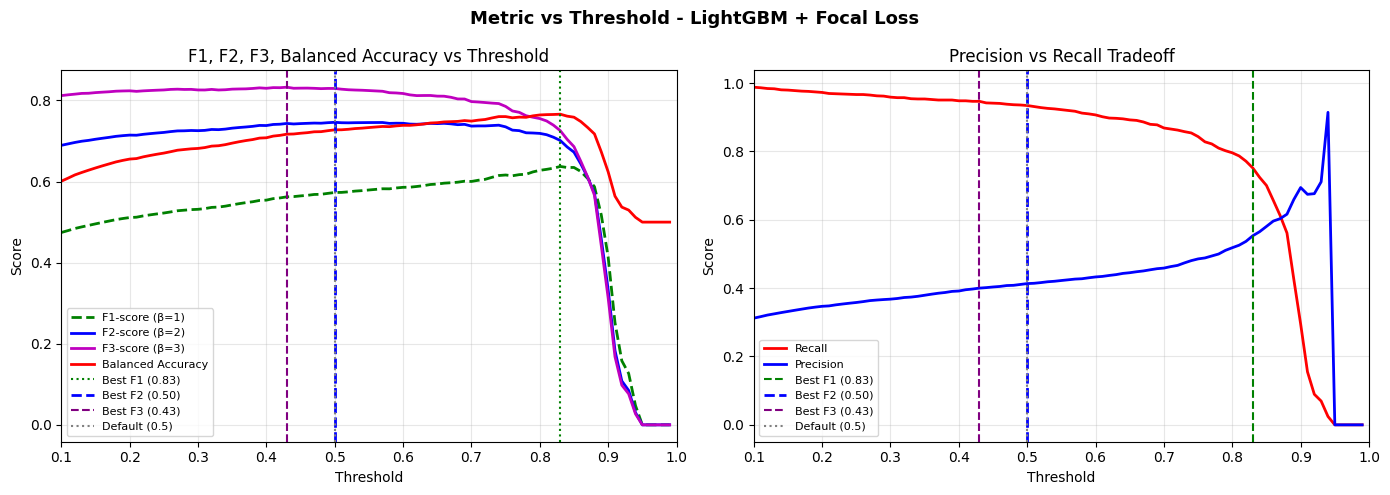

In [ ]:
# Finding best threshold - F1, F2 (β=2), F3 (β=3)
# Using out of fold (OOF) predictions to avoid overfitting bias

thresholds = np.arange(0.1, 1, 0.01)
threshold_results = []

for t in thresholds:
    y_pred = (oof_predictions >= t).astype(int)
    threshold_results.append({
        'threshold': t,
        'f1':        fbeta_score(y_train, y_pred, beta=1, zero_division=0),
        'f2':        fbeta_score(y_train, y_pred, beta=2, zero_division=0),
        'f3':        fbeta_score(y_train, y_pred, beta=3, zero_division=0),
        'recall':    recall_score(y_train, y_pred, zero_division=0),
        'precision': precision_score(y_train, y_pred, zero_division=0),
        'bal_acc':   balanced_accuracy_score(y_train, y_pred)
    })

thresh_df = pd.DataFrame(threshold_results)

best_thresh_f1 = thresh_df.loc[thresh_df['f1'].idxmax(), 'threshold']
best_thresh_f2 = thresh_df.loc[thresh_df['f2'].idxmax(), 'threshold']
best_thresh_f3 = thresh_df.loc[thresh_df['f3'].idxmax(), 'threshold']

print(f"Best threshold by F1-score (β=1): {best_thresh_f1:.2f}")
print(f"Best threshold by F2-score (β=2): {best_thresh_f2:.2f}")
print(f"Best threshold by F3-score (β=3): {best_thresh_f3:.2f}")

print(f"\nAt best F1 threshold ({best_thresh_f1:.2f}):")
print(thresh_df[thresh_df['threshold'] == best_thresh_f1].to_string(index=False))

print(f"\nAt best F2 threshold ({best_thresh_f2:.2f}):")
print(thresh_df[thresh_df['threshold'] == best_thresh_f2].to_string(index=False))

print(f"\nAt best F3 threshold ({best_thresh_f3:.2f}):")
print(thresh_df[thresh_df['threshold'] == best_thresh_f3].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Metric vs Threshold - LightGBM + Focal Loss',
             fontsize=13, fontweight='bold')

ax1 = axes[0]
ax1.plot(thresh_df['threshold'], thresh_df['f1'],      'g--', linewidth=2, label='F1-score (β=1)')
ax1.plot(thresh_df['threshold'], thresh_df['f2'],      'b-',  linewidth=2, label='F2-score (β=2)')
ax1.plot(thresh_df['threshold'], thresh_df['f3'],      'm-',  linewidth=2, label='F3-score (β=3)')
ax1.plot(thresh_df['threshold'], thresh_df['bal_acc'], 'r-',  linewidth=2, label='Balanced Accuracy')
ax1.axvline(x=best_thresh_f1, color='green',  linestyle=':', linewidth=1.5, label=f'Best F1 ({best_thresh_f1:.2f})')
ax1.axvline(x=best_thresh_f2, color='blue',   linestyle='--', linewidth=2,  label=f'Best F2 ({best_thresh_f2:.2f})')
ax1.axvline(x=best_thresh_f3, color='purple', linestyle='--', linewidth=1.5, label=f'Best F3 ({best_thresh_f3:.2f})')
ax1.axvline(x=0.5,            color='grey',   linestyle=':',  linewidth=1.5,  label='Default (0.5)')
ax1.set_xlabel('Threshold')
ax1.set_ylabel('Score')
ax1.set_title('F1, F2, F3, Balanced Accuracy vs Threshold')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0.1, 1)


ax2 = axes[1]
ax2.plot(thresh_df['threshold'], thresh_df['recall'],    'r-', linewidth=2, label='Recall')
ax2.plot(thresh_df['threshold'], thresh_df['precision'], 'b-', linewidth=2, label='Precision')
ax2.axvline(x=best_thresh_f1, color='green',  linestyle='--', linewidth=1.5, label=f'Best F1 ({best_thresh_f1:.2f})')
ax2.axvline(x=best_thresh_f2, color='blue',   linestyle='--', linewidth=2,   label=f'Best F2 ({best_thresh_f2:.2f})')
ax2.axvline(x=best_thresh_f3, color='purple', linestyle='--', linewidth=1.5,  label=f'Best F3 ({best_thresh_f3:.2f})')
ax2.axvline(x=0.5,            color='grey',   linestyle=':',  linewidth=1.5,  label='Default (0.5)')
ax2.set_xlabel('Threshold')
ax2.set_ylabel('Score')
ax2.set_title('Precision vs Recall Tradeoff')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0.1, 1)

plt.tight_layout()
plt.show()

In [ ]:
# Based on F2, we decide that best threshold for LGBM is 0.5
FINAL_LGBM_THRESHOLD = 0.50

### D.6 - Logistic Regression baseline

In [ ]:
_LR_FILES = ['lr_model.pkl', 'lr_oof_predictions.pkl']

if checkpoint_exists(*_LR_FILES):
    print("LR model and OOF predictions already exist")
    with open(save_path + 'lr_model.pkl', 'rb') as f:
        lr_model = pickle.load(f)
    with open(save_path + 'lr_oof_predictions.pkl', 'rb') as f:
        lr_oof_predictions = pickle.load(f)

else:
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=2026)
    lr_oof_predictions = np.zeros(len(X_train))

    for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
        X_fold_train = X_train.iloc[train_idx]
        y_fold_train = y_train.iloc[train_idx]
        X_fold_val   = X_train.iloc[val_idx]

        fold_model = LogisticRegression(max_iter=1000, random_state=2026, class_weight='balanced')
        fold_model.fit(X_fold_train, y_fold_train)
        lr_oof_predictions[val_idx] = fold_model.predict_proba(X_fold_val)[:, 1]

    lr_thresh_results = []
    for t in np.arange(0.1, 0.9, 0.01):
        y_pred = (lr_oof_predictions >= t).astype(int)
        lr_thresh_results.append({
            'threshold': t,
            'f1': fbeta_score(y_train, y_pred, beta=1, zero_division=0),
            'f2': fbeta_score(y_train, y_pred, beta=2, zero_division=0),
            'recall': recall_score(y_train, y_pred, zero_division=0),
            'precision': precision_score(y_train, y_pred, zero_division=0),
        })
    lr_thresh_df = pd.DataFrame(lr_thresh_results)
    _best_lr_t = lr_thresh_df.loc[lr_thresh_df['f2'].idxmax(), 'threshold']
    print(f"LR optimal threshold (F2, OOF): {_best_lr_t:.2f}")
    print(lr_thresh_df[lr_thresh_df['threshold'] == _best_lr_t].to_string(index=False))

    # Training LR model on full training set

    lr_model = LogisticRegression(max_iter=1000, random_state=2026, class_weight='balanced')
    lr_model.fit(X_train, y_train)

    with open(save_path + 'lr_model.pkl', 'wb') as f:
        pickle.dump(lr_model, f)
    with open(save_path + 'lr_oof_predictions.pkl', 'wb') as f:
        pickle.dump(lr_oof_predictions, f)

LR optimal threshold (F2, OOF): 0.31
 threshold       f1      f2  recall  precision
      0.31 0.586198 0.74891 0.91896   0.430362


In [ ]:
FINAL_LR_THRESHOLD   = 0.31

### D.7 - Evaluation

In [ ]:
# Evaluation

def evaluate_batch(model, X_batch, y_batch, model_type='lgbm'):
    if model_type == 'lgbm':
        raw = model.predict(X_batch)
        proba = 1 / (1 + np.exp(-raw))
        y_pred = (proba >= FINAL_LGBM_THRESHOLD).astype(int)
    else:
        proba = model.predict_proba(X_batch)[:, 1]
        y_pred = (proba >= FINAL_LR_THRESHOLD).astype(int)

    return {
        'auc':       roc_auc_score(y_batch, proba),
        'f1':        f1_score(y_batch, y_pred, zero_division=0),
        'f2':        fbeta_score(y_batch, y_pred, beta=2, zero_division=0),
        'precision': precision_score(y_batch, y_pred, zero_division=0),
        'recall':    recall_score(y_batch, y_pred, zero_division=0),
        'bal_acc':   balanced_accuracy_score(y_batch, y_pred)
    }

lgbm_results = []
lr_results   = []

print(f"{'Batch':<8}| {'LGBM AUC':<10} {'LGBM F1':<10} {'LGBM F2':<10} {'LGBM prec':<10} {'LGBM rec':<10} {'LGBM bal':<10} "
      f"| {'LR AUC':<10} {'LR F1':<10} {'LR F2':<10} {'LR prec':<10} {'LR rec':<10} {'LR bal':<10} | Drift?")
print("-" * 155)

for i, (bx, by) in enumerate(zip(drifted_batches_X, drifted_batches_y)):
    lgbm_res = evaluate_batch(final_model, bx, by, model_type='lgbm')
    lr_res   = evaluate_batch(lr_model,    bx, by, model_type='lr')

    lgbm_results.append(lgbm_res)
    lr_results.append(lr_res)

    drift_label = "DRIFT" if i >= 5 else "stable"
    print(f"{i+1:<8}| {lgbm_res['auc']:<10.4f} {lgbm_res['f1']:<10.4f} {lgbm_res['f2']:<10.4f} "
          f"{lgbm_res['precision']:<10.4f} {lgbm_res['recall']:<10.4f} {lgbm_res['bal_acc']:<10.4f} "
          f"| {lr_res['auc']:<10.4f} {lr_res['f1']:<10.4f} {lr_res['f2']:<10.4f} "
          f"{lr_res['precision']:<10.4f} {lr_res['recall']:<10.4f} {lr_res['bal_acc']:<10.4f} | {drift_label}")

Batch   | LGBM AUC   LGBM F1    LGBM F2    LGBM prec  LGBM rec   LGBM bal   | LR AUC     LR F1      LR F2      LR prec    LR rec     LR bal     | Drift?
-----------------------------------------------------------------------------------------------------------------------------------------------------------
1       | 0.8583     0.5795     0.7544     0.4180     0.9444     0.7461     | 0.8585     0.5904     0.7470     0.4375     0.9074     0.7531     | stable
2       | 0.8966     0.6484     0.8082     0.4876     0.9672     0.7769     | 0.9039     0.6552     0.7983     0.5044     0.9344     0.7805     | stable
3       | 0.8576     0.5455     0.7434     0.3778     0.9808     0.7262     | 0.8509     0.5495     0.7396     0.3846     0.9615     0.7292     | stable
4       | 0.8280     0.5172     0.7075     0.3571     0.9375     0.7203     | 0.8300     0.4970     0.6634     0.3504     0.8542     0.6940     | stable
5       | 0.7897     0.5829     0.7360     0.4328     0.8923     0.6859     | 0

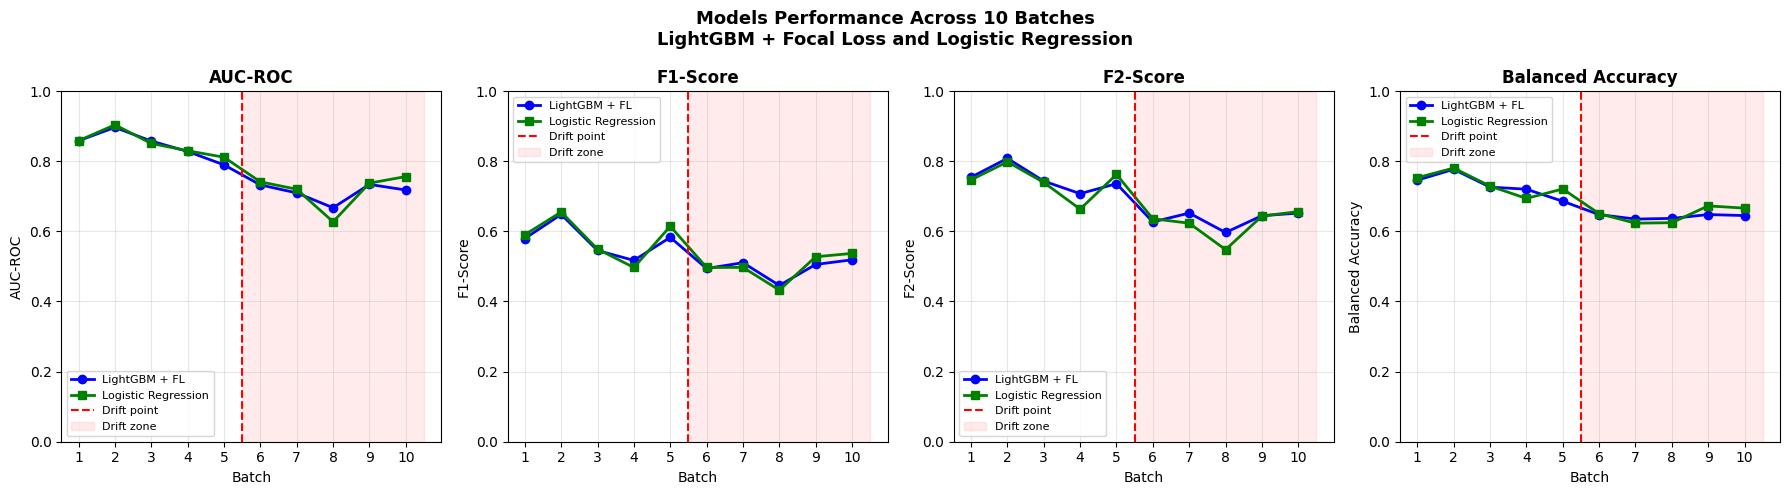

In [ ]:
# Plotting

batches_idx = list(range(1, 11))
metrics = ['auc', 'f1', 'f2', 'bal_acc']
titles  = ['AUC-ROC', 'F1-Score', 'F2-Score', 'Balanced Accuracy']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Models Performance Across 10 Batches\nLightGBM + Focal Loss and Logistic Regression',
             fontsize=13, fontweight='bold')

for ax, metric, title in zip(axes, metrics, titles):
    lgbm_vals = [r[metric] for r in lgbm_results]
    lr_vals   = [r[metric] for r in lr_results]

    ax.plot(batches_idx, lgbm_vals, 'b-o', label='LightGBM + FL', linewidth=2)
    ax.plot(batches_idx, lr_vals,   'g-s', label='Logistic Regression', linewidth=2)
    ax.axvline(x=5.5, color='red', linestyle='--', linewidth=1.5, label='Drift point')
    ax.axvspan(5.5, 10.5, alpha=0.08, color='red', label='Drift zone')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Batch')
    ax.set_ylabel(title)
    ax.set_xticks(batches_idx)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

---
## E - River ARF (Continual Learning)

### E.1 - Helpers and pretraining batches

In [ ]:
# Converting a pandas row into a dict so river could use it.

def row_to_dict(row):
    return row.to_dict()

In [ ]:
N_PRETRAIN_BATCHES = 23

X_train_reset = X_train.reset_index(drop=True)
y_train_reset = y_train.reset_index(drop=True)

pretrain_batch_size = len(X_train_reset) // N_PRETRAIN_BATCHES

pretrain_batches_X = []
pretrain_batches_y = []

for i in range(N_PRETRAIN_BATCHES):
    start = i * pretrain_batch_size
    end   = start + pretrain_batch_size if i < N_PRETRAIN_BATCHES - 1 else len(X_train_reset)
    pretrain_batches_X.append(X_train_reset.iloc[start:end].reset_index(drop=True))
    pretrain_batches_y.append(y_train_reset.iloc[start:end].reset_index(drop=True))

print(f"pretraining batches: {N_PRETRAIN_BATCHES}")
for i, (bx, by) in enumerate(zip(pretrain_batches_X, pretrain_batches_y)):
    print(f"  Batch {i+1}: {len(bx)} rows, churn rate: {by.mean():.2%}")

pretraining batches: 23
  Batch 1: 214 rows, churn rate: 30.37%
  Batch 2: 214 rows, churn rate: 27.10%
  Batch 3: 214 rows, churn rate: 22.90%
  Batch 4: 214 rows, churn rate: 32.24%
  Batch 5: 214 rows, churn rate: 28.50%
  Batch 6: 214 rows, churn rate: 23.83%
  Batch 7: 214 rows, churn rate: 23.36%
  Batch 8: 214 rows, churn rate: 29.44%
  Batch 9: 214 rows, churn rate: 28.97%
  Batch 10: 214 rows, churn rate: 24.77%
  Batch 11: 214 rows, churn rate: 27.10%
  Batch 12: 214 rows, churn rate: 26.64%
  Batch 13: 214 rows, churn rate: 27.57%
  Batch 14: 214 rows, churn rate: 29.44%
  Batch 15: 214 rows, churn rate: 31.31%
  Batch 16: 214 rows, churn rate: 31.78%
  Batch 17: 214 rows, churn rate: 26.17%
  Batch 18: 214 rows, churn rate: 21.50%
  Batch 19: 214 rows, churn rate: 27.10%
  Batch 20: 214 rows, churn rate: 25.23%
  Batch 21: 214 rows, churn rate: 22.43%
  Batch 22: 214 rows, churn rate: 19.16%
  Batch 23: 222 rows, churn rate: 23.42%


In [ ]:
# Churn rates are not very evenly distributed.

In [ ]:
# Next function runs ARF through batches prequentially (predict then learn)
# Returns the trained model and all predictions and labels collected.

def prequential_pretrain(batches_X, batches_y, use_weighting=False, churn_weight=3, seed=2026):

    model = forest.ARFClassifier(n_models=10, seed=seed, drift_detector=drift.ADWIN(delta=0.01), warning_detector=drift.ADWIN(delta=0.1))

    probs  = []
    labels = []

    # These will store, for every single customer the model encounters, the probability it predicted before learning from that customer, and the customer's true label.
    # They are out of fold data, used later for threshold tuning.

    for bx, by in zip(batches_X, batches_y):
        for i in range(len(bx)):
            x = row_to_dict(bx.iloc[i])
            y = int(by.iloc[i])

            # Predict first
            proba = model.predict_proba_one(x)
            p_churn = proba.get(1, 0.0)

            # model.predict_proba_one(x) returns probabilities for each class.
            # get(1, 0.0) pulls out the probability of class 1 (churn)
            # the 0.0 default handles the edge case where the model has never seen class 1 yet and might not have a "1" key at all.

            probs.append(p_churn)
            labels.append(y)

            # Then learn
            # The call is repeated to simulate weighting for churners
            # sample_weight is not functionally supported by ARFClassifier in this
            #  River version, confirmed empirically; repetition mirrors ARF's own
            #  Poisson bagging mechanism (Gomes et al., 2017)
            n_updates = churn_weight if (use_weighting and y == 1) else 1
            for _ in range(n_updates):
                model.learn_one(x, y)

    return model, np.array(probs), np.array(labels)

In [ ]:
def find_best_threshold_f2(probs, labels, thresholds=np.arange(0.1, 0.9, 0.01)):

    results = []
    for t in thresholds:
        preds = (probs >= t).astype(int)
        results.append({
            'threshold': t,
            'f1':        f1_score(labels, preds, zero_division=0),
            'f2':        fbeta_score(labels, preds, beta=2, zero_division=0),
            'recall':    recall_score(labels, preds, zero_division=0),
            'precision': precision_score(labels, preds, zero_division=0),
            'balanced_accuracy': balanced_accuracy_score(labels, preds),
            'roc_auc':   roc_auc_score(labels, probs),
        })

    df = pd.DataFrame(results)
    best_row = df.loc[df['f2'].idxmax()]
    return best_row['threshold'], df

### E.2 — Weight sensitivity



 churn_weight  best_threshold     f1     f2  recall  precision  balanced_accuracy  roc_auc
            1            0.19 0.5430 0.7145  0.9052     0.3878             0.6946   0.8089
            2            0.28 0.5487 0.7248  0.9220     0.3905             0.7012   0.8085
            3            0.29 0.5292 0.7166  0.9381     0.3686             0.6789   0.8048
            4            0.36 0.5414 0.7216  0.9274     0.3823             0.6931   0.7988
            5            0.45 0.5546 0.7148  0.8853     0.4038             0.7066   0.7975
            6            0.37 0.5118 0.7055  0.9434     0.3512             0.6570   0.7881
            7            0.45 0.5408 0.7093  0.8953     0.3874             0.6920   0.7905
            8            0.39 0.5063 0.7028  0.9480     0.3454             0.6496   0.7753
            9            0.44 0.5220 0.7035  0.9159     0.3650             0.6703   0.7780
           10            0.43 0.5257 0.7151  0.9411     0.3647             0.6746   0.7780

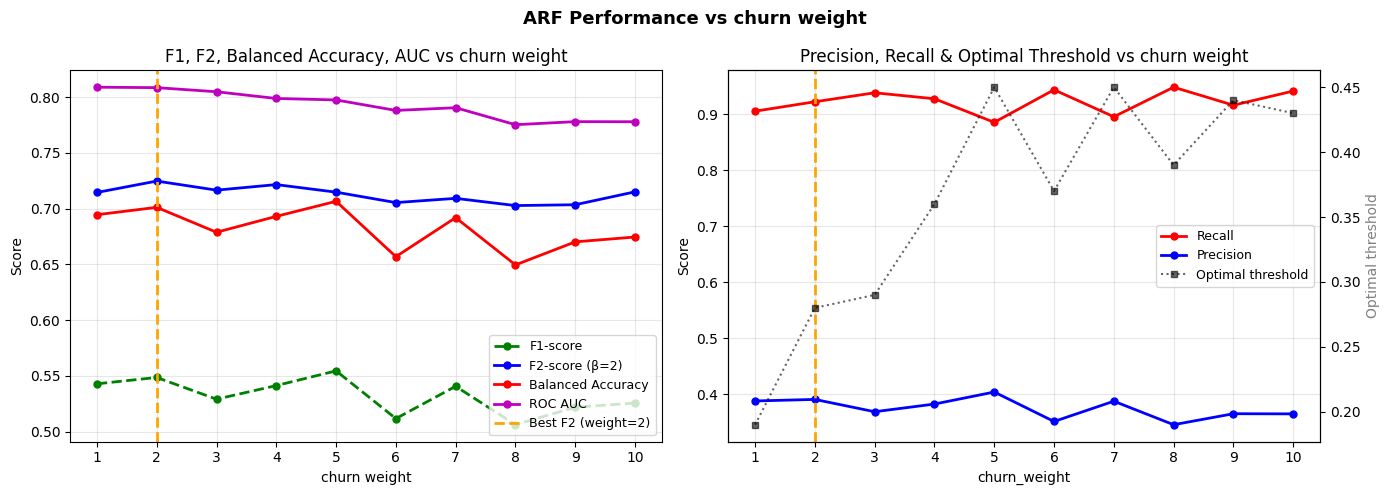

In [ ]:
# trying all weights for ARF model in range 1 to 10 (seed = 2026)

weight_range = range(1, 11)

weight_sweep_results = []

for w in weight_range:
    use_w = (w != 1)

    arf_model, oof_probs, oof_labels = prequential_pretrain(
        pretrain_batches_X, pretrain_batches_y,
        use_weighting=use_w,
        churn_weight=w,
        seed=2026
    )

    best_thresh, thresh_df = find_best_threshold_f2(oof_probs, oof_labels)
    best_row = thresh_df.loc[thresh_df['f2'].idxmax()]

    weight_sweep_results.append({
        'churn_weight':      w,
        'best_threshold':    best_thresh,
        'f1':                best_row['f1'],
        'f2':                best_row['f2'],
        'recall':            best_row['recall'],
        'precision':         best_row['precision'],
        'balanced_accuracy': best_row['balanced_accuracy'],
        'roc_auc':           best_row['roc_auc'],
    })

sweep_df = pd.DataFrame(weight_sweep_results)

print(sweep_df.round(4).to_string(index=False))

best_weight_row = sweep_df.loc[sweep_df['f2'].idxmax()]
print(f"\nBest churn_weight by F2: {best_weight_row['churn_weight']} "
      f"(F2={best_weight_row['f2']:.4f})")


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ARF Performance vs churn weight',
             fontsize=13, fontweight='bold')

ax1 = axes[0]
ax1.plot(sweep_df['churn_weight'], sweep_df['f1'],  'g--o', linewidth=2, markersize=5, label='F1-score')
ax1.plot(sweep_df['churn_weight'], sweep_df['f2'],  'b-o',  linewidth=2, markersize=5, label='F2-score (β=2)')
ax1.plot(sweep_df['churn_weight'], sweep_df['balanced_accuracy'], 'r-o', linewidth=2, markersize=5, label='Balanced Accuracy')
ax1.plot(sweep_df['churn_weight'], sweep_df['roc_auc'], 'm-o', linewidth=2, markersize=5, label='ROC AUC')
best_w = best_weight_row['churn_weight']
ax1.axvline(x=best_w, color='orange', linestyle='--', linewidth=2,
           label=f'Best F2 (weight={int(best_w)})')
ax1.set_xlabel('churn weight')
ax1.set_ylabel('Score')
ax1.set_title('F1, F2, Balanced Accuracy, AUC vs churn weight')
ax1.set_xticks(list(weight_range))
ax1.legend(fontsize=9, loc='lower right')
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.plot(sweep_df['churn_weight'], sweep_df['recall'],    'r-o', linewidth=2, markersize=5, label='Recall')
ax2.plot(sweep_df['churn_weight'], sweep_df['precision'], 'b-o', linewidth=2, markersize=5, label='Precision')
ax2_twin = ax2.twinx()
ax2_twin.plot(sweep_df['churn_weight'], sweep_df['best_threshold'], 'k:s',
             linewidth=1.5, markersize=5, label='Optimal threshold', alpha=0.6)
ax2_twin.set_ylabel('Optimal threshold', color='grey')
ax2.axvline(x=best_w, color='orange', linestyle='--', linewidth=2)
ax2.set_xlabel('churn_weight')
ax2.set_ylabel('Score')
ax2.set_title('Precision, Recall & Optimal Threshold vs churn weight')
ax2.set_xticks(list(weight_range))

lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='center right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

 churn_weight  best_threshold     f1     f2  recall  precision  balanced_accuracy  roc_auc
            1            0.22 0.5760 0.7281  0.8838     0.4272             0.7279   0.8173
            2            0.30 0.5603 0.7293  0.9128     0.4042             0.7135   0.8072
            3            0.36 0.5603 0.7264  0.9052     0.4058             0.7132   0.8066
            4            0.42 0.5567 0.7192  0.8930     0.4044             0.7090   0.8023
            5            0.34 0.5271 0.7174  0.9450     0.3655             0.6762   0.8010
            6            0.41 0.5392 0.7195  0.9258     0.3803             0.6906   0.7954
            7            0.41 0.5292 0.7134  0.9289     0.3700             0.6788   0.7883
            8            0.43 0.5233 0.7058  0.9197     0.3657             0.6718   0.7820
            9            0.45 0.5224 0.7019  0.9106     0.3662             0.6708   0.7722
           10            0.48 0.5278 0.7011  0.8976     0.3738             0.6772   0.7725

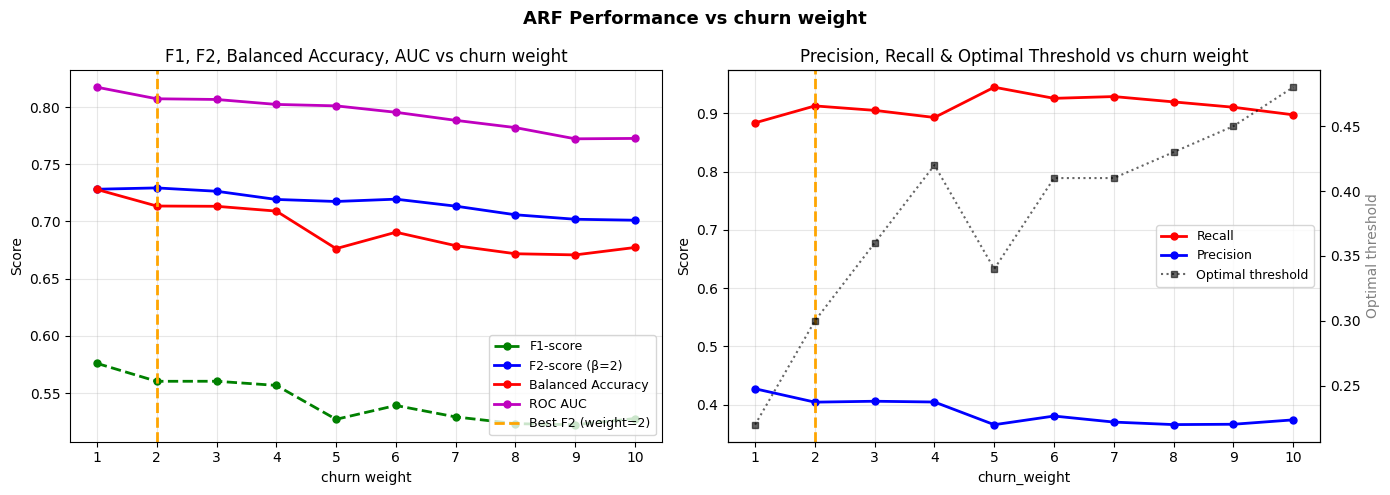

In [ ]:
# trying all weights in range 1 to 10 (seed = 42)

weight_range = range(1, 11)

weight_sweep_results = []

for w in weight_range:
    use_w = (w != 1)

    arf_model, oof_probs, oof_labels = prequential_pretrain(
        pretrain_batches_X, pretrain_batches_y,
        use_weighting=use_w,
        churn_weight=w,
        seed=42
    )

    best_thresh, thresh_df = find_best_threshold_f2(oof_probs, oof_labels)
    best_row = thresh_df.loc[thresh_df['f2'].idxmax()]

    weight_sweep_results.append({
        'churn_weight':      w,
        'best_threshold':    best_thresh,
        'f1':                best_row['f1'],
        'f2':                best_row['f2'],
        'recall':            best_row['recall'],
        'precision':         best_row['precision'],
        'balanced_accuracy': best_row['balanced_accuracy'],
        'roc_auc':           best_row['roc_auc'],
    })

sweep_df = pd.DataFrame(weight_sweep_results)

print(sweep_df.round(4).to_string(index=False))

best_weight_row = sweep_df.loc[sweep_df['f2'].idxmax()]
print(f"\nBest churn_weight by F2: {best_weight_row['churn_weight']} "
      f"(F2={best_weight_row['f2']:.4f})")


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ARF Performance vs churn weight',
             fontsize=13, fontweight='bold')

ax1 = axes[0]
ax1.plot(sweep_df['churn_weight'], sweep_df['f1'],  'g--o', linewidth=2, markersize=5, label='F1-score')
ax1.plot(sweep_df['churn_weight'], sweep_df['f2'],  'b-o',  linewidth=2, markersize=5, label='F2-score (β=2)')
ax1.plot(sweep_df['churn_weight'], sweep_df['balanced_accuracy'], 'r-o', linewidth=2, markersize=5, label='Balanced Accuracy')
ax1.plot(sweep_df['churn_weight'], sweep_df['roc_auc'], 'm-o', linewidth=2, markersize=5, label='ROC AUC')
best_w = best_weight_row['churn_weight']
ax1.axvline(x=best_w, color='orange', linestyle='--', linewidth=2,
           label=f'Best F2 (weight={int(best_w)})')
ax1.set_xlabel('churn weight')
ax1.set_ylabel('Score')
ax1.set_title('F1, F2, Balanced Accuracy, AUC vs churn weight')
ax1.set_xticks(list(weight_range))
ax1.legend(fontsize=9, loc='lower right')
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.plot(sweep_df['churn_weight'], sweep_df['recall'],    'r-o', linewidth=2, markersize=5, label='Recall')
ax2.plot(sweep_df['churn_weight'], sweep_df['precision'], 'b-o', linewidth=2, markersize=5, label='Precision')
ax2_twin = ax2.twinx()
ax2_twin.plot(sweep_df['churn_weight'], sweep_df['best_threshold'], 'k:s',
             linewidth=1.5, markersize=5, label='Optimal threshold', alpha=0.6)
ax2_twin.set_ylabel('Optimal threshold', color='grey')
ax2.axvline(x=best_w, color='orange', linestyle='--', linewidth=2)
ax2.set_xlabel('churn_weight')
ax2.set_ylabel('Score')
ax2.set_title('Precision, Recall & Optimal Threshold vs churn weight')
ax2.set_xticks(list(weight_range))

lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='center right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# A churn_weight sweep (1–10) was run with two different seeds (2026 and 42)
# to test whether instance-repetition weighting improves ARF performance.
# F2 stayed within a narrow band (0.7 – 0.73) in both runs.
# It is concluded to be noise, not a real effect. The final decision is an unweighted model.
# So, we'll just use unweighted model and model is capable of handling imbalancness by itself

### E.3 - Training the final ARF model


In [ ]:
_ARF_PRETRAIN_FILES = ['arf_pretrained_model.pkl', 'arf_oof_predictions.pkl']

if checkpoint_exists(*_ARF_PRETRAIN_FILES):
    print("Pretrained ARF model and OOF predictions already exists")
    with open(save_path + 'arf_pretrained_model.pkl', 'rb') as f:
        final_arf = pickle.load(f)
    with open(save_path + 'arf_oof_predictions.pkl', 'rb') as f:
        _arf_oof = pickle.load(f)
    arf_oof_probs  = _arf_oof['probs']
    arf_oof_labels = _arf_oof['labels']
    arf_threshold  = _arf_oof['threshold']
    print(f"Loaded pretrained ARF, threshold={arf_threshold:.2f}")

else:
    final_arf, arf_oof_probs, arf_oof_labels = prequential_pretrain(
        pretrain_batches_X, pretrain_batches_y,
        use_weighting=False,
        seed=2026
    )

    arf_threshold, arf_thresh_df = find_best_threshold_f2(arf_oof_probs, arf_oof_labels)
    print(f"ARF optimal threshold (F2, OOF): {arf_threshold:.2f}")

    with open(save_path + 'arf_pretrained_model.pkl', 'wb') as f:
        pickle.dump(final_arf, f)
    with open(save_path + 'arf_oof_predictions.pkl', 'wb') as f:
        pickle.dump({'probs': arf_oof_probs, 'labels': arf_oof_labels, 'threshold': arf_threshold}, f)

ARF optimal threshold (F2, OOF): 0.19


In [ ]:
pretrain_perf = []
idx = 0
for i, bx in enumerate(pretrain_batches_X):
    n = len(bx)
    batch_probs  = arf_oof_probs[idx: idx + n]
    batch_labels = arf_oof_labels[idx: idx + n]

    y_pred = (batch_probs >= arf_threshold).astype(int)
    pretrain_perf.append({
        'Batch':    i + 1,
        'AUC':      roc_auc_score(batch_labels, batch_probs) if len(set(batch_labels)) > 1 else np.nan,
        'F1':       f1_score(batch_labels, y_pred, zero_division=0),
        'F2':       fbeta_score(batch_labels, y_pred, beta=2, zero_division=0),
        'Precision':precision_score(batch_labels, y_pred, zero_division=0),
        'Recall':   recall_score(batch_labels, y_pred, zero_division=0),
        'Bal_Acc':  balanced_accuracy_score(batch_labels, y_pred),
    })
    idx += n

pretrain_perf_df = pd.DataFrame(pretrain_perf)

print(f"Pretraining batches processed: {len(pretrain_perf_df)}")
print(pretrain_perf_df.round(4).to_string(index=False))

pretrain_perf_df.to_pickle(save_path + 'arf_pretrain_perf.pkl')

Pretraining batches processed: 23
 Batch    AUC     F1     F2  Precision  Recall  Bal_Acc
     1 0.6056 0.4715 0.6576     0.3204  0.8923   0.5334
     2 0.8603 0.5714 0.7438     0.4122  0.9310   0.7187
     3 0.7583 0.4607 0.6509     0.3099  0.8980   0.6520
     4 0.7873 0.5766 0.7459     0.4183  0.9275   0.6569
     5 0.8336 0.5700 0.7441     0.4101  0.9344   0.6992
     6 0.7941 0.4947 0.6851     0.3381  0.9216   0.6786
     7 0.7707 0.4972 0.6728     0.3465  0.8800   0.6870
     8 0.8353 0.6193 0.7902     0.4552  0.9683   0.7424
     9 0.8333 0.5743 0.7474     0.4143  0.9355   0.6980
    10 0.8392 0.5269 0.7101     0.3684  0.9245   0.7014
    11 0.7604 0.5326 0.6844     0.3889  0.8448   0.6756
    12 0.8219 0.5622 0.7303     0.4062  0.9123   0.7141
    13 0.8273 0.5500 0.7294     0.3901  0.9322   0.6887
    14 0.8527 0.6243 0.7804     0.4683  0.9365   0.7464
    15 0.7929 0.5900 0.7357     0.4436  0.8806   0.6886
    16 0.8149 0.5980 0.7475     0.4485  0.8971   0.6917
    17 0.8599 

### E.4 — Prequential evaluation across the 10 drifted batches

In [ ]:
# Next function runs ARF through batches prequentially, continuing to update the same model across all batches.
# Returns per batch metrics.

In [ ]:
def evaluate_arf_prequential(model, batches_X, batches_y, threshold):

    results = []

    for batch_idx, (bx, by) in enumerate(zip(batches_X, batches_y)):
        batch_probs  = []
        batch_labels = []

        for i in range(len(bx)):
            x = row_to_dict(bx.iloc[i])
            y = int(by.iloc[i])

            proba = model.predict_proba_one(x)
            p_churn = proba.get(1, 0.0)
            batch_probs.append(p_churn)
            batch_labels.append(y)

            model.learn_one(x, y)

        batch_probs  = np.array(batch_probs)
        batch_labels = np.array(batch_labels)
        y_pred = (batch_probs >= threshold).astype(int)

        results.append({
            'batch':     batch_idx + 1,
            'auc':       roc_auc_score(batch_labels, batch_probs) if len(set(batch_labels)) > 1 else np.nan,
            'f1':        fbeta_score(batch_labels, y_pred, beta=1, zero_division=0),
            'f2':        fbeta_score(batch_labels, y_pred, beta=2, zero_division=0),
            'precision': precision_score(batch_labels, y_pred, zero_division=0),
            'recall':    recall_score(batch_labels, y_pred, zero_division=0),
            'bal_acc':   balanced_accuracy_score(batch_labels, y_pred),
        })

    return pd.DataFrame(results), model

In [ ]:
_ARF_EVAL_FILES = ['arf_drift_eval_results.pkl', 'arf_trained_final.pkl']

if checkpoint_exists(*_ARF_EVAL_FILES):
    print("ARF drift-evaluation results already exist")
    arf_results_df = pd.read_pickle(save_path + 'arf_drift_eval_results.pkl')
    with open(save_path + 'arf_trained_final.pkl', 'rb') as f:
        final_arf_trained = pickle.load(f)

else:
    arf_results_df, final_arf_trained = evaluate_arf_prequential(
        final_arf, drifted_batches_X, drifted_batches_y, threshold=arf_threshold
    )

    arf_results_df.to_pickle(save_path + 'arf_drift_eval_results.pkl')
    with open(save_path + 'arf_trained_final.pkl', 'wb') as f:
        pickle.dump(final_arf_trained, f)

print(f"\n{'Batch':<8} {'AUC':<10} {'F1':<10} {'F2':<10} {'Precision':<12} {'Recall':<10} {'Bal_Acc':<10} {'Drift?'}")
print("-" * 85)
for _, row in arf_results_df.iterrows():
    drift_label = "DRIFT" if row['batch'] >= 6 else "stable"
    print(f"{int(row['batch']):<8} {row['auc']:<10.4f} {row['f1']:<10.4f} {row['f2']:<10.4f} "
          f"{row['precision']:<12.4f} {row['recall']:<10.4f} {row['bal_acc']:<10.4f} {drift_label}")


Batch    AUC        F1         F2         Precision    Recall     Bal_Acc    Drift?
-------------------------------------------------------------------------------------
1        0.8451     0.5833     0.7424     0.4298       0.9074     0.7467     stable
2        0.8965     0.6628     0.8028     0.5135       0.9344     0.7872     stable
3        0.8275     0.5484     0.7456     0.3806       0.9808     0.7294     stable
4        0.8332     0.5276     0.7003     0.3739       0.8958     0.7271     stable
5        0.7743     0.6020     0.7545     0.4504       0.9077     0.7073     stable
6        0.7223     0.4944     0.6414     0.3577       0.8000     0.6468     DRIFT
7        0.7543     0.5474     0.7027     0.4000       0.8667     0.6751     DRIFT
8        0.6796     0.4457     0.6113     0.3071       0.8125     0.6363     DRIFT
9        0.7447     0.5652     0.7324     0.4094       0.9123     0.7126     DRIFT
10       0.8273     0.5787     0.7500     0.4191       0.9344     0.7090     

In [ ]:
# Saving ARF's actual prequential predictions for dashboard use.

with open(save_path + 'drifted_batches.pkl', 'rb') as f:
    _drift_data = pickle.load(f)

drifted_batches_X = _drift_data['X']
drifted_batches_y = _drift_data['y']

print(f"Loaded {len(drifted_batches_X)} drifted batches ✓")


_arf_for_dashboard, _, _ = prequential_pretrain(
    pretrain_batches_X, pretrain_batches_y,
    use_weighting=False,
    seed=2026
)

def evaluate_arf_prequential_capture_probs(model, batches_X, batches_y):
    all_batch_probs = []
    for bx, by in zip(batches_X, batches_y):
        batch_probs = []
        for i in range(len(bx)):
            x = row_to_dict(bx.iloc[i])
            y = int(by.iloc[i])
            proba = model.predict_proba_one(x)
            batch_probs.append(proba.get(1, 0.0))
            model.learn_one(x, y)
        all_batch_probs.append(np.array(batch_probs))
    return all_batch_probs

arf_dashboard_probs = evaluate_arf_prequential_capture_probs(
    _arf_for_dashboard, drifted_batches_X, drifted_batches_y
)

with open(save_path + 'arf_dashboard_predictions.pkl', 'wb') as f:
    pickle.dump({
        'batch_probs': arf_dashboard_probs,
        'threshold': arf_threshold
    }, f)

print(f"Saved probabilities for {len(arf_dashboard_probs)} batches")

Loaded 10 drifted batches ✓
Saved probabilities for 10 batches


In [ ]:
print(f"{'Batch':<8}{'AUC':<10}{'F2':<10}")
for i, (probs, y_true) in enumerate(zip(arf_dashboard_probs, drifted_batches_y)):
    y_pred = (probs >= arf_threshold).astype(int)
    auc = roc_auc_score(y_true, probs)
    f2 = fbeta_score(y_true, y_pred, beta=2, zero_division=0)
    print(f"{i+1:<8}{auc:<10.4f}{f2:<10.4f}")

Batch   AUC       F2        
1       0.8451    0.7424    
2       0.8965    0.8028    
3       0.8275    0.7456    
4       0.8332    0.7003    
5       0.7743    0.7545    
6       0.7223    0.6414    
7       0.7543    0.7027    
8       0.6796    0.6113    
9       0.7447    0.7324    
10      0.8273    0.7500    


---
## F - Comparison: Static Models vs Continual Learning (ARF) Under Drift

In [ ]:
# Assembling the three result sets into DataFrames for plotting

lgbm_df = pd.DataFrame(lgbm_results)
lgbm_df.insert(0, 'batch', range(1, len(lgbm_df) + 1))

lr_df = pd.DataFrame(lr_results)
lr_df.insert(0, 'batch', range(1, len(lr_df) + 1))

arf_df = arf_results_df.copy()

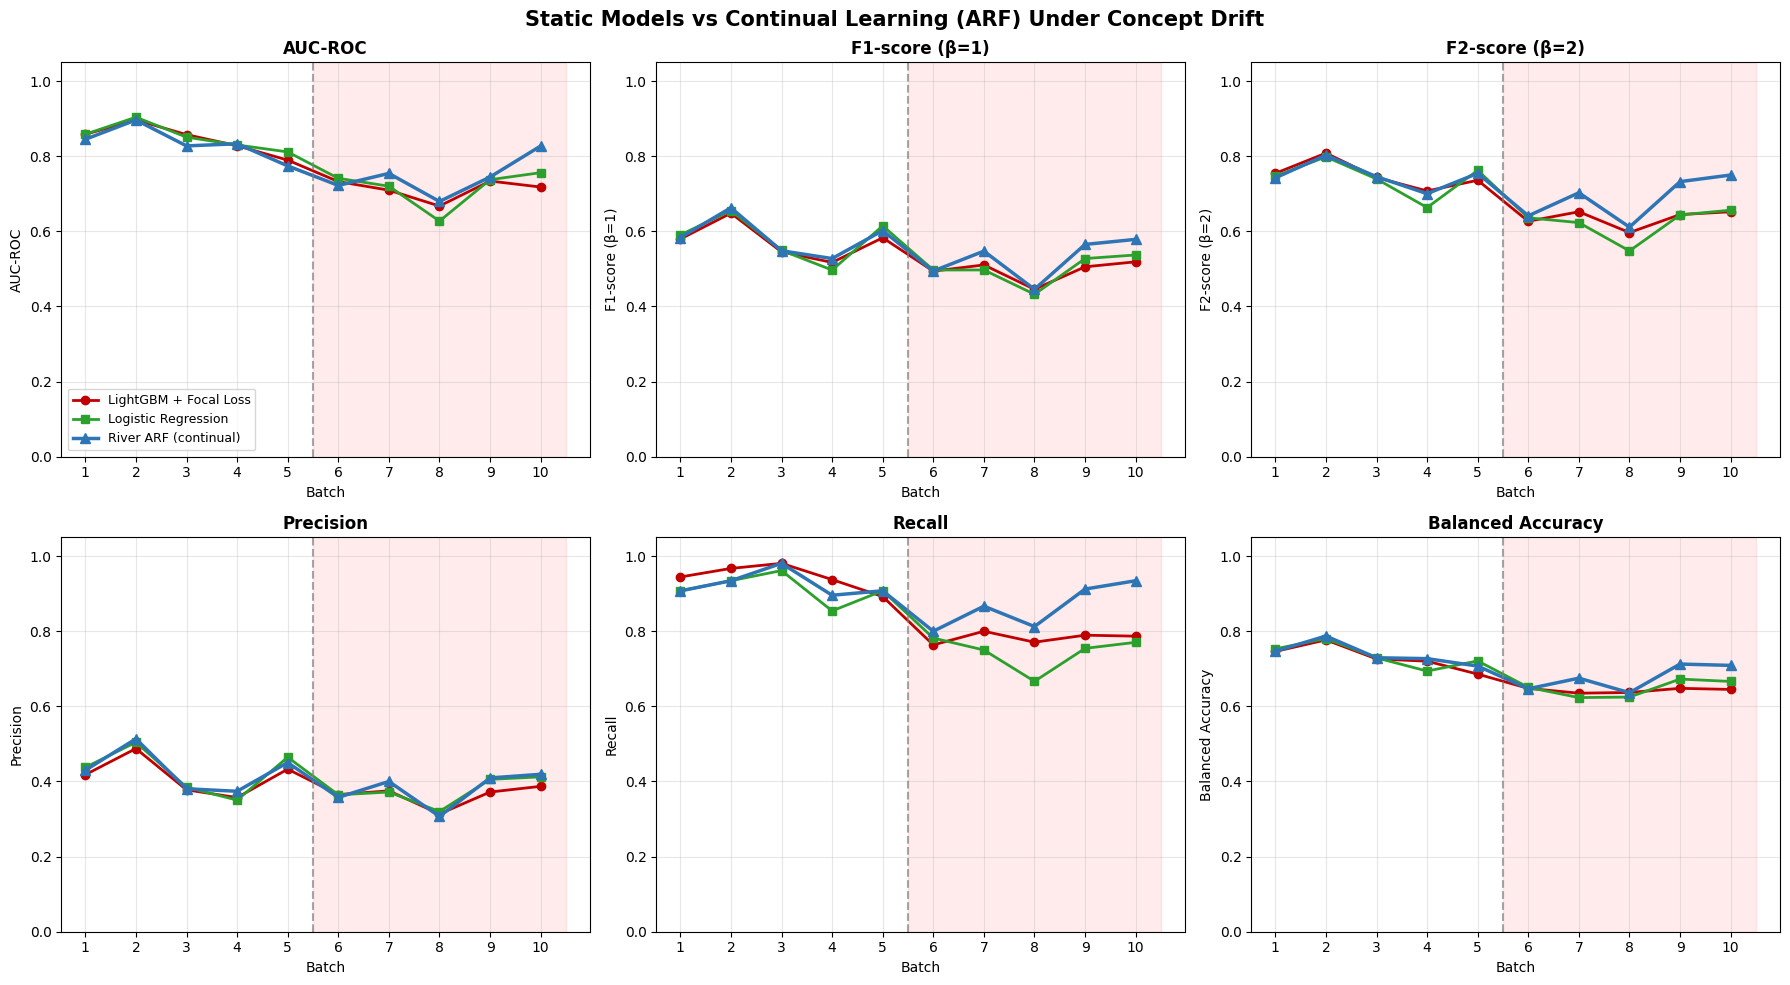

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Static Models vs Continual Learning (ARF) Under Concept Drift',
             fontsize=15, fontweight='bold')

metrics = ['auc', 'f1', 'f2', 'precision', 'recall', 'bal_acc']
titles  = ['AUC-ROC', 'F1-score (β=1)', 'F2-score (β=2)',
          'Precision', 'Recall', 'Balanced Accuracy']
colors  = {'LGBM': '#C00000', 'LR': '#2CA02C', 'ARF': '#2E75B6'}

axes_flat = axes.flatten()

for ax, metric, title in zip(axes_flat, metrics, titles):
    ax.plot(lgbm_df['batch'], lgbm_df[metric], 'o-', color=colors['LGBM'],
           linewidth=2, markersize=6, label='LightGBM + Focal Loss')
    ax.plot(lr_df['batch'], lr_df[metric], 's-', color=colors['LR'],
           linewidth=2, markersize=6, label='Logistic Regression')
    ax.plot(arf_df['batch'], arf_df[metric], '^-', color=colors['ARF'],
           linewidth=2.5, markersize=7, label='River ARF (continual)')

    ax.axvline(x=5.5, color='grey', linestyle='--', linewidth=1.5, alpha=0.7)
    ax.axvspan(5.5, 10.5, alpha=0.08, color='red')

    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_xlabel('Batch')
    ax.set_ylabel(title)
    ax.set_xticks(list(range(1, 11)))
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1.05)

axes_flat[0].legend(fontsize=9, loc='lower left')

plt.tight_layout()
plt.show()

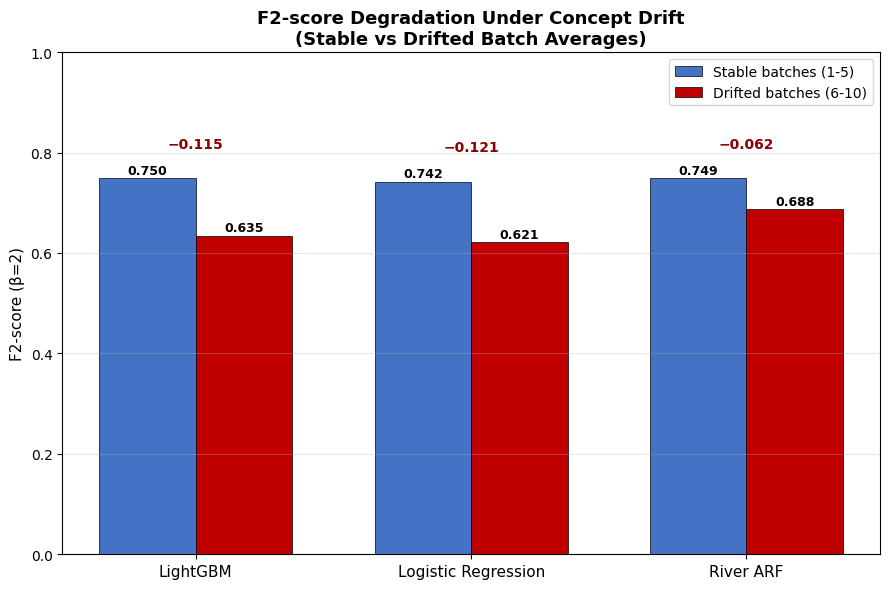

In [ ]:
def avg_stable_drifted(df, metric):
    stable = df[df['batch'] <= 5][metric].mean()
    drifted = df[df['batch'] > 5][metric].mean()
    return stable, drifted

models = ['LightGBM', 'Logistic Regression', 'River ARF']
dfs    = [lgbm_df, lr_df, arf_df]

fig, ax = plt.subplots(figsize=(9, 6))
x = np.arange(len(models))
width = 0.35

stable_vals  = [avg_stable_drifted(df, 'f2')[0] for df in dfs]
drifted_vals = [avg_stable_drifted(df, 'f2')[1] for df in dfs]

bars1 = ax.bar(x - width/2, stable_vals, width, label='Stable batches (1-5)',
              color='#4472C4', edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x + width/2, drifted_vals, width, label='Drifted batches (6-10)',
              color='#C00000', edgecolor='black', linewidth=0.5)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                   xytext=(0, 3), textcoords="offset points", ha='center',
                   fontsize=9, fontweight='bold')

for i, (s, d) in enumerate(zip(stable_vals, drifted_vals)):
    drop = s - d
    ax.annotate(f'−{drop:.3f}', xy=(i, max(s, d) + 0.06),
               ha='center', fontsize=10, color='darkred', fontweight='bold')

ax.set_ylabel('F2-score (β=2)', fontsize=11)
ax.set_title('F2-score Degradation Under Concept Drift\n(Stable vs Drifted Batch Averages)',
            fontweight='bold', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.legend(fontsize=10)
ax.set_ylim(0, 1.0)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [ ]:
# checking for drift and warnings in ARF model training.

_diag_model = forest.ARFClassifier(
    n_models=10,
    seed=2026,
    drift_detector=drift.ADWIN(delta=0.01),
    warning_detector=drift.ADWIN(delta=0.1),
)

all_batches_X = pretrain_batches_X + drifted_batches_X
all_batches_y = pretrain_batches_y + drifted_batches_y

batch_records = []

for batch_idx, (bx, by) in enumerate(zip(all_batches_X, all_batches_y)):
    for i in range(len(bx)):
        x = row_to_dict(bx.iloc[i])
        y = int(by.iloc[i])
        _diag_model.predict_proba_one(x)
        _diag_model.learn_one(x, y)

    batch_records.append({
        'batch':            batch_idx + 1,
        'n_drifts_total':   _diag_model.n_drifts_detected(),
        'n_warnings_total': _diag_model.n_warnings_detected(),
    })

drift_track_df = pd.DataFrame(batch_records)
drift_track_df['new_drifts']   = drift_track_df['n_drifts_total'].diff().fillna(drift_track_df['n_drifts_total'].iloc[0])
drift_track_df['new_warnings'] = drift_track_df['n_warnings_total'].diff().fillna(drift_track_df['n_warnings_total'].iloc[0])

N_PRETRAIN = len(pretrain_batches_X)
print(f"Pretraining batches: 1-{N_PRETRAIN}")

print(drift_track_df.to_string(index=False))

Pretraining batches: 1-23
 batch  n_drifts_total  n_warnings_total  new_drifts  new_warnings
     1               0                 0         0.0           0.0
     2               0                 0         0.0           0.0
     3               0                 0         0.0           0.0
     4               0                 0         0.0           0.0
     5               0                 0         0.0           0.0
     6               0                 0         0.0           0.0
     7               0                 0         0.0           0.0
     8               0                 0         0.0           0.0
     9               0                 0         0.0           0.0
    10               0                 0         0.0           0.0
    11               0                 0         0.0           0.0
    12               0                 0         0.0           0.0
    13               0                 0         0.0           0.0
    14               0              

In [ ]:
# running statistical tests on drift batches.

In [ ]:
lgbm_f2 = lgbm_df['f2'].values
lr_f2   = lr_df['f2'].values
arf_f2  = arf_df['f2'].values

lgbm_stable, lgbm_drifted = lgbm_f2[:5], lgbm_f2[5:]
lr_stable,   lr_drifted   = lr_f2[:5],   lr_f2[5:]
arf_stable,  arf_drifted  = arf_f2[:5],  arf_f2[5:]

In [ ]:
# H0: mean(LGBM_stable) = mean(LR_stable) = mean(ARF_stable)
# H1: at least one model's stable-period mean differs from the others

f_stat, p_anova = stats.f_oneway(lgbm_stable, lr_stable, arf_stable)

print(f"LGBM stable mean: {lgbm_stable.mean():.4f}")
print(f"LR   stable mean: {lr_stable.mean():.4f}")
print(f"ARF  stable mean: {arf_stable.mean():.4f}")
print(f"One-way ANOVA: F={f_stat:.3f}, p={p_anova:.4f}")

LGBM stable mean: 0.7499
LR   stable mean: 0.7421
ARF  stable mean: 0.7491
One-way ANOVA: F=0.054, p=0.9478


In [ ]:
# For each model:
# H0: mean(stable F2) <= mean(drifted F2)
# H1: mean(stable F2) >  mean(drifted F2)   (performance degraded under drift)

def within_model_test(stable, drifted, model_name):
    t_stat, t_p = stats.ttest_ind(stable, drifted, alternative='greater')
    u_stat, u_p = stats.mannwhitneyu(stable, drifted, alternative='greater')

    print(f"\n{model_name}: stable batches vs drifted batches:")
    print(f"  Stable:  mean={stable.mean():.4f}, std={stable.std(ddof=1):.4f}")
    print(f"  Drifted: mean={drifted.mean():.4f}, std={drifted.std(ddof=1):.4f}")
    print(f"  Drop:    {stable.mean() - drifted.mean():+.4f}")
    print(f"  One-tailed t-test:         t={t_stat:.3f}  p={t_p:.4f}")
    print(f"  One-tailed Mann-Whitney U: U={u_stat:.1f}  p={u_p:.4f}")

    return {
        'model': model_name,
        'stable_mean': stable.mean(), 'drifted_mean': drifted.mean(),
        'drop': stable.mean() - drifted.mean(),
        't_stat': t_stat, 't_p': t_p, 'u_stat': u_stat, 'u_p': u_p,
    }

results_within = []
results_within.append(within_model_test(lgbm_stable, lgbm_drifted, 'LightGBM'))
results_within.append(within_model_test(lr_stable, lr_drifted, 'Logistic Regression'))
results_within.append(within_model_test(arf_stable, arf_drifted, 'River ARF'))

within_df = pd.DataFrame(results_within)
print("\n" + "="*70)
print("SUMMARY")
print(within_df.round(4).to_string(index=False))


LightGBM: stable batches vs drifted batches:
  Stable:  mean=0.7499, std=0.0369
  Drifted: mean=0.6345, std=0.0235
  Drop:    +0.1154
  One-tailed t-test:         t=5.897  p=0.0002
  One-tailed Mann-Whitney U: U=25.0  p=0.0060

Logistic Regression: stable batches vs drifted batches:
  Stable:  mean=0.7421, std=0.0495
  Drifted: mean=0.6215, std=0.0428
  Drop:    +0.1206
  One-tailed t-test:         t=4.123  p=0.0017
  One-tailed Mann-Whitney U: U=25.0  p=0.0040

River ARF: stable batches vs drifted batches:
  Stable:  mean=0.7491, std=0.0366
  Drifted: mean=0.6876, std=0.0593
  Drop:    +0.0616
  One-tailed t-test:         t=1.975  p=0.0418
  One-tailed Mann-Whitney U: U=20.0  p=0.0754

SUMMARY
              model  stable_mean  drifted_mean   drop  t_stat    t_p  u_stat    u_p
           LightGBM       0.7499        0.6345 0.1154  5.8968 0.0002    25.0 0.0060
Logistic Regression       0.7421        0.6215 0.1206  4.1225 0.0017    25.0 0.0040
          River ARF       0.7491        0.6

In [ ]:
# For each static model:
# H0: mean(ARF_drifted) <= mean(static_drifted)
# H1: mean(ARF_drifted) >  mean(static_drifted)

def paired_comparison(arf_scores, other_scores, other_name):
    diffs = arf_scores - other_scores
    wins_arf = np.sum(diffs > 0)

    t_stat, t_p = stats.ttest_rel(arf_scores, other_scores, alternative='greater')
    w_stat, w_p = stats.wilcoxon(arf_scores, other_scores, alternative='greater')

    d = diffs.mean() / diffs.std(ddof=1) if diffs.std(ddof=1) > 0 else np.nan

    print(f"\nARF vs {other_name} on drifted batches:")
    print(f"  ARF mean:   {arf_scores.mean():.4f}")
    print(f"  {other_name} mean:  {other_scores.mean():.4f}")
    print(f"  Mean difference: {diffs.mean():+.4f}")
    print(f"  ARF wins in {wins_arf}/{len(diffs)} batches")
    print(f"  Cohen's d (paired): {d:.3f}")
    print(f"  Paired t-test:        t={t_stat:.3f}  p={t_p:.4f}")
    print(f"  Wilcoxon signed-rank: W={w_stat:.1f}  p={w_p:.4f}")

    return {
        'comparison': f'ARF vs {other_name}',
        'mean_diff': diffs.mean(), 'wins': f'{wins_arf}/{len(diffs)}',
        'cohens_d': d, 't_stat': t_stat, 't_p': t_p,
        'w_stat': w_stat, 'w_p': w_p,
    }

results_between = []
results_between.append(paired_comparison(arf_drifted, lgbm_drifted, 'LGBM'))
results_between.append(paired_comparison(arf_drifted, lr_drifted, 'LR'))

between_df = pd.DataFrame(results_between)
print("\n" + "="*70)
print("SUMMARY — ARF vs static models under drift:")
print(between_df.round(4).to_string(index=False))


ARF vs LGBM on drifted batches:
  ARF mean:   0.6876
  LGBM mean:  0.6345
  Mean difference: +0.0530
  ARF wins in 5/5 batches
  Cohen's d (paired): 1.349
  Paired t-test:        t=3.016  p=0.0197
  Wilcoxon signed-rank: W=15.0  p=0.0312

ARF vs LR on drifted batches:
  ARF mean:   0.6876
  LR mean:  0.6215
  Mean difference: +0.0661
  ARF wins in 5/5 batches
  Cohen's d (paired): 1.842
  Paired t-test:        t=4.119  p=0.0073
  Wilcoxon signed-rank: W=15.0  p=0.0312

SUMMARY — ARF vs static models under drift:
 comparison  mean_diff wins  cohens_d  t_stat    t_p  w_stat    w_p
ARF vs LGBM     0.0530  5/5    1.3488  3.0161 0.0197    15.0 0.0312
  ARF vs LR     0.0661  5/5    1.8419  4.1186 0.0073    15.0 0.0312


In [ ]:
# Note: minimum possible one-tailed Wilcoxon p at n=5 is 0.03125

In [ ]:
# H0: mean(ARF extended stable batches F2, n=28) <= mean(ARF drifted F2, n=5)
# H1: mean(ARF extended stable batches F2, n=28) >  mean(ARF drifted F2, n=5)
# Extended stable = 5 evaluation stable batches + 23 pretraining batches;
# tests whether the significant degradation found in the primary 5-vs-5
# comparison is robust to a broader definition of the stable baseline
# that includes ARFs cold start pretraining period.

In [ ]:
arf_pretrain_f2 = pretrain_perf_df['F2'].values          # n=23
arf_eval_stable_f2 = arf_f2[:5]                          # n=5
arf_eval_drifted_f2 = arf_f2[5:]                         # n=5

arf_extended_stable = np.concatenate([arf_pretrain_f2, arf_eval_stable_f2])

t_stat, t_p = stats.ttest_ind(arf_extended_stable, arf_eval_drifted_f2, alternative='greater')
u_stat, u_p = stats.mannwhitneyu(arf_extended_stable, arf_eval_drifted_f2, alternative='greater')

print("robustness check: ARF stable (n=28, incl. pretraining) vs drifted (n=5):")
print(f"Extended stable mean: {arf_extended_stable.mean():.4f}, std: {arf_extended_stable.std(ddof=1):.4f}")
print(f"Drifted mean:         {arf_eval_drifted_f2.mean():.4f}, std: {arf_eval_drifted_f2.std(ddof=1):.4f}")
print(f"Drop: {arf_extended_stable.mean() - arf_eval_drifted_f2.mean():.4f}")
print(f"One-tailed t-test:         t={t_stat:.3f}, p={t_p:.4f}")
print(f"One-tailed Mann-Whitney U: U={u_stat:.1f}, p={u_p:.4f}")

robustness check: ARF stable (n=28, incl. pretraining) vs drifted (n=5):
Extended stable mean: 0.7185, std: 0.0459
Drifted mean:         0.6876, std: 0.0593
Drop: 0.0309
One-tailed t-test:         t=1.331, p=0.0964
One-tailed Mann-Whitney U: U=89.0, p=0.1765


## G - Explainibility: SHAP

In [ ]:
# As the final_model was trained with a custom Focal Loss objective, not built in binary,
# SHAP values are computed on the model's raw margin scale, consistent with the manual sigmoid transformation.

/tmp/ipykernel_1294/2061236344.py:9: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_train, X_train, show=False)


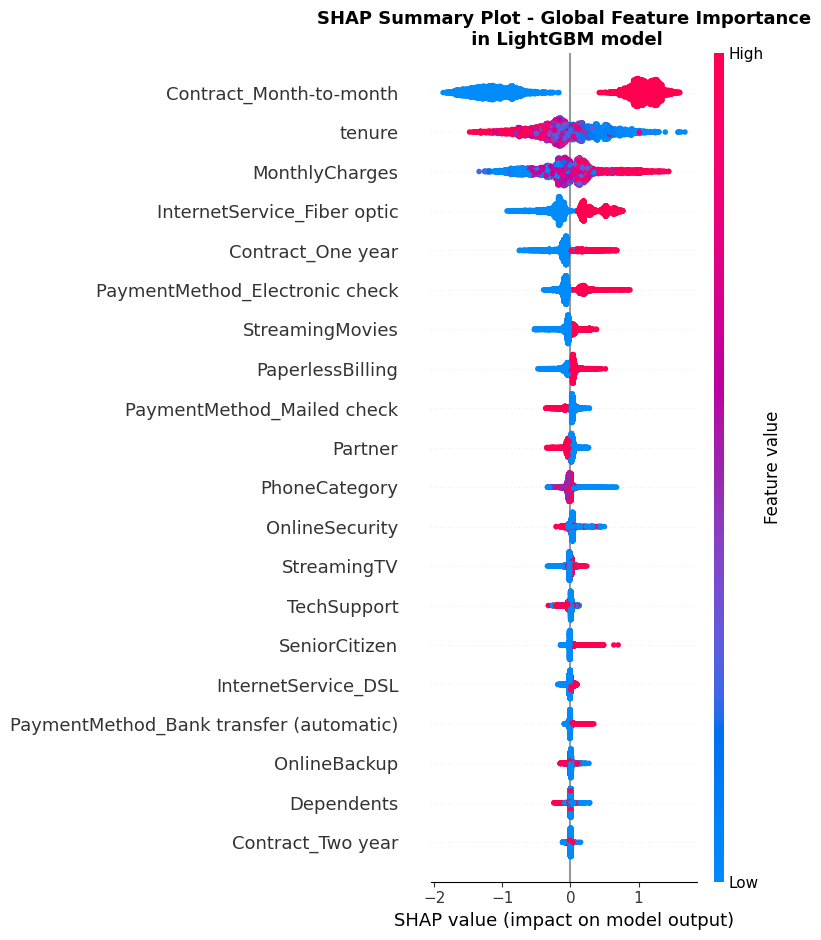

In [ ]:
explainer = shap.TreeExplainer(final_model)

shap_values_train = explainer.shap_values(X_train)

if isinstance(shap_values_train, list):
    shap_values_train = shap_values_train[1]

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_train, X_train, show=False)
plt.title('SHAP Summary Plot - Global Feature Importance\n in LightGBM model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

SHAP global feature importance:
                                feature  mean_abs_shap
                Contract_Month-to-month         1.1130
                                 tenure         0.3946
                         MonthlyCharges         0.3350
            InternetService_Fiber optic         0.2903
                      Contract_One year         0.1467
         PaymentMethod_Electronic check         0.1348
                        StreamingMovies         0.0786
                       PaperlessBilling         0.0680
             PaymentMethod_Mailed check         0.0634
                                Partner         0.0431
                          PhoneCategory         0.0400
                         OnlineSecurity         0.0379
                            StreamingTV         0.0338
                            TechSupport         0.0259
                          SeniorCitizen         0.0257
                    InternetService_DSL         0.0201
PaymentMethod_Bank transfer (auto

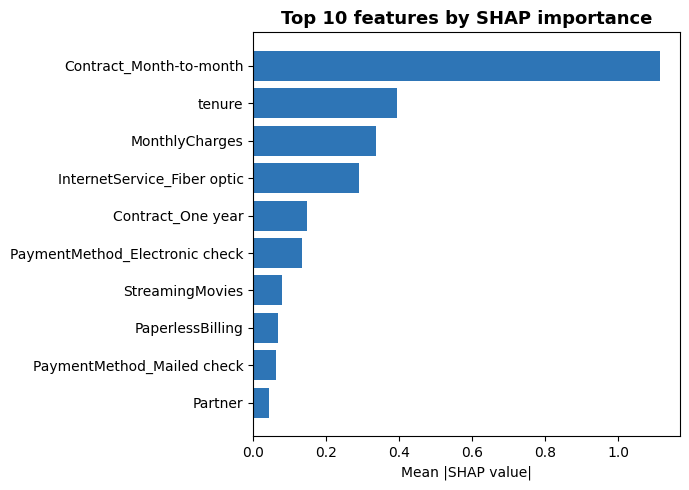

In [ ]:
mean_abs_shap = np.abs(shap_values_train).mean(axis=0)
shap_importance = pd.DataFrame({
    'feature': X_train.columns,
    'mean_abs_shap': mean_abs_shap
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

print("SHAP global feature importance:")
print(shap_importance.round(4).to_string(index=False))

plt.figure(figsize=(7, 5))
plt.barh(shap_importance['feature'][:10][::-1], shap_importance['mean_abs_shap'][:10][::-1],
          color='#2E75B6')
plt.xlabel('Mean |SHAP value|')
plt.title('Top 10 features by SHAP importance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()



In [ ]:
print("Comparison: SHAP vs Gain Ratio (from information gain) top 5:")
print("SHAP top 5:      ", list(shap_importance['feature'][:5]))
print("Gain Ratio top 5: [Contract, InternetService, tenure, PaymentMethod, OnlineSecurity]")

Comparison: SHAP vs Gain Ratio (from information gain) top 5:
SHAP top 5:       ['Contract_Month-to-month', 'tenure', 'MonthlyCharges', 'InternetService_Fiber optic', 'Contract_One year']
Gain Ratio top 5: [Contract, InternetService, tenure, PaymentMethod, OnlineSecurity]


In [ ]:
# Reverse the StandardScaler transformation for display purposes only.

numerical_cols = ['tenure', 'MonthlyCharges']

X_train_display = X_train.copy()
X_train_display[numerical_cols] = scaler.inverse_transform(X_train_display[numerical_cols])

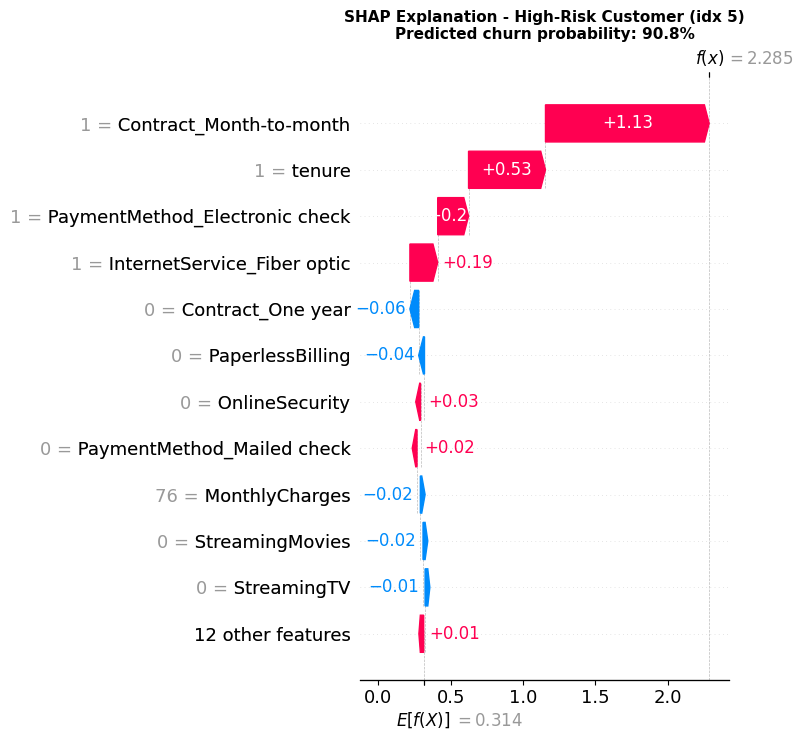

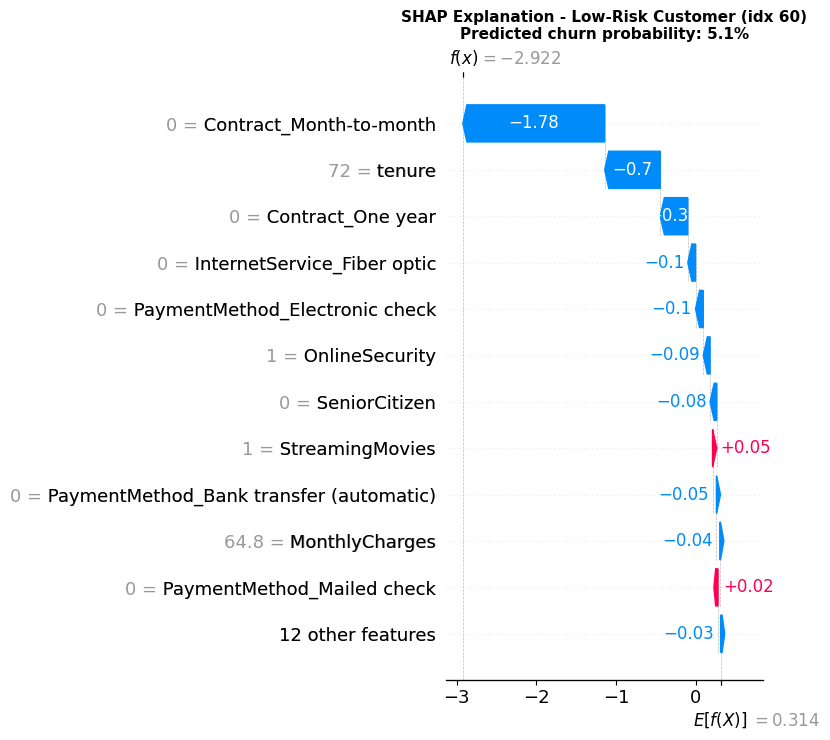

In [ ]:
# Using a stable unseen batch as an examples:

example_X = drifted_batches_X[0].reset_index(drop=True)

numerical_cols = ['tenure', 'MonthlyCharges']
example_X_display = example_X.copy()
example_X_display[numerical_cols] = scaler.inverse_transform(example_X_display[numerical_cols])

raw_pred_ex  = final_model.predict(example_X)
prob_pred_ex = 1 / (1 + np.exp(-raw_pred_ex))

high_risk_idx = int(np.argmax(prob_pred_ex))
low_risk_idx  = int(np.argmin(prob_pred_ex))

shap_values_example = explainer.shap_values(example_X)
if isinstance(shap_values_example, list):
    shap_values_example = shap_values_example[1]

expected_value = explainer.expected_value
if isinstance(expected_value, (list, np.ndarray)):
    expected_value = expected_value[1] if len(np.atleast_1d(expected_value)) > 1 else expected_value[0]

for idx, label in [(high_risk_idx, 'High-Risk'), (low_risk_idx, 'Low-Risk')]:
    explanation = shap.Explanation(
        values=shap_values_example[idx],
        base_values=expected_value,
        data=example_X_display.iloc[idx].values,
        feature_names=example_X.columns.tolist()
    )

    plt.figure(figsize=(9, 6))
    shap.plots.waterfall(explanation, max_display=12, show=False)
    plt.title(f'SHAP Explanation - {label} Customer (idx {idx})\nPredicted churn probability: {prob_pred_ex[idx]:.1%}',
              fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [ ]:
X_train_display.columns

Index(['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges',
       'PhoneCategory', 'InternetService_DSL', 'InternetService_Fiber optic',
       'InternetService_No', 'Contract_Month-to-month', 'Contract_One year',
       'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')

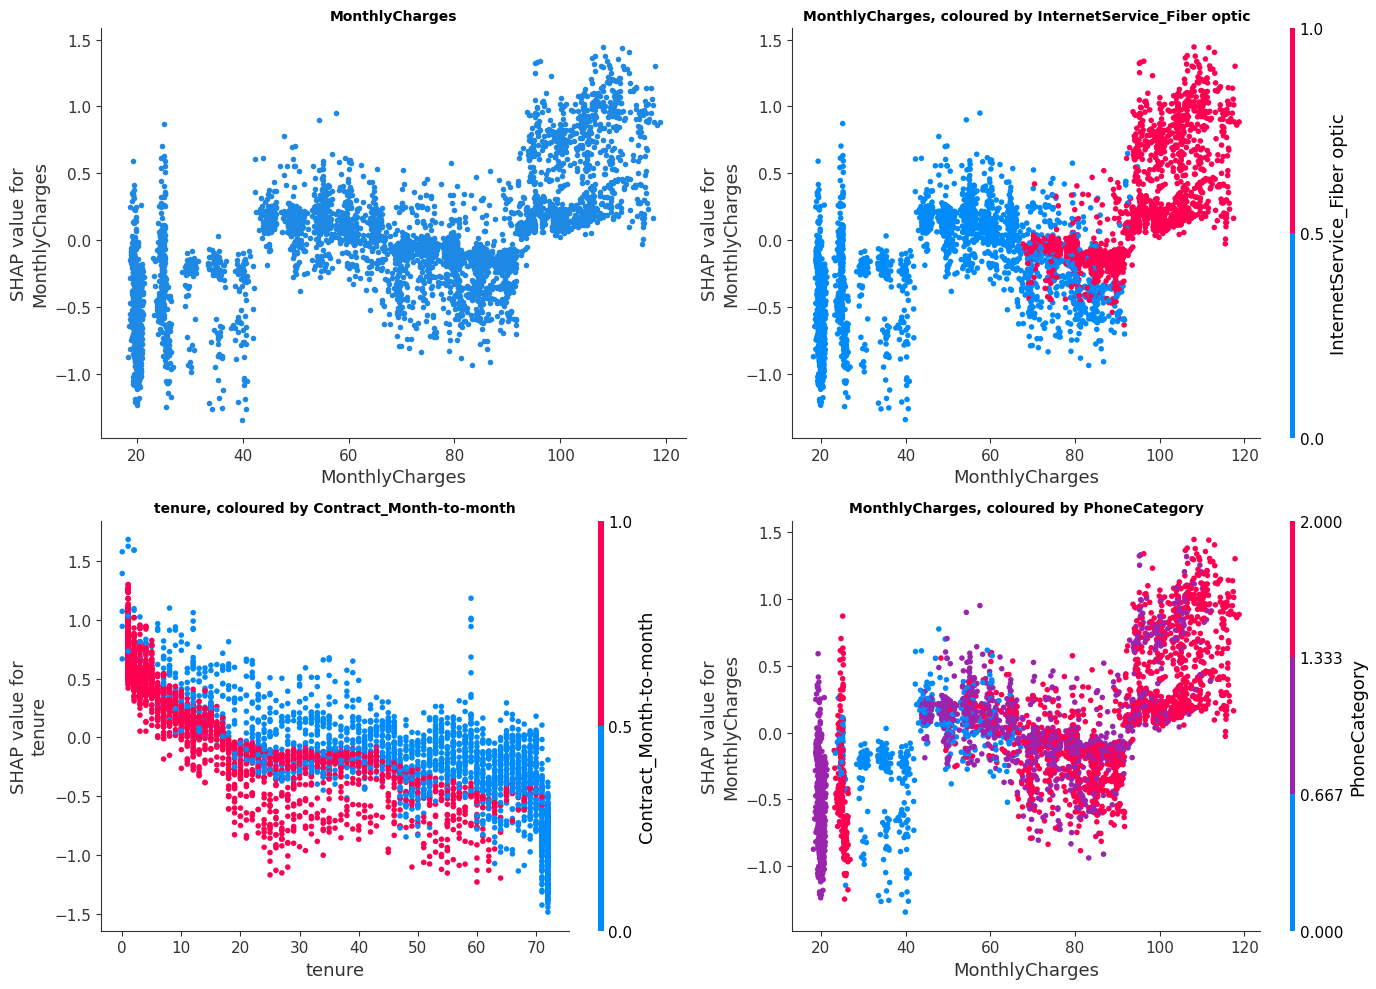

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

pairs = [
    ('MonthlyCharges', None, 'MonthlyCharges'),
    ('MonthlyCharges', 'InternetService_Fiber optic', 'MonthlyCharges, coloured by InternetService_Fiber optic'),
    ('tenure', 'Contract_Month-to-month', 'tenure, coloured by Contract_Month-to-month'),
    ('MonthlyCharges', 'PhoneCategory', 'MonthlyCharges, coloured by PhoneCategory'),
]

for ax, (main_feat, interact_feat, title) in zip(axes, pairs):
    shap.dependence_plot(
        main_feat,
        shap_values_train,
        X_train_display,
        interaction_index=interact_feat,
        ax=ax,
        show=False
    )
    ax.set_title(title, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()